In [1]:
# Standard library
import math
import warnings
from pathlib import Path
from collections import Counter

# Third-party scientific stack
import pandas as pd
import numpy as np

# Scientific computing
import statsmodels.formula.api as smf

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Network analysis
import networkx as nx
import community as community_louvain
from pyvis.network import Network

# Local project utilities
from utils.conv_clustering import (
    analyze_clusters,
    patient_celltype_distribution,
    plot_patient_clustermap_middle_colorbar,
)

# Global settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Matplotlib configuration
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["font.family"] = "Arial"

In [2]:
# Base directory of the files
base_dir = Path("..").resolve()

# Directories containing the processed files
processed_dir = base_dir / "2_processed_data" / "3_discovery_convergence"
conv_dir = base_dir / "2_processed_data" / "6_combined_convergence"
conv_correction_dir = base_dir / "2_processed_data" / "9_conv_correction"

# Output directories for the figures and tables
figures_dir = base_dir / "3_figures" / "Figures"
tables_dir = base_dir / "3_figures" / "Tables"
suppl_dir = base_dir / "3_figures" / "Supplementary"

# overview convergence files
convergence_summary = pd.read_csv(conv_dir / "5_convergence_summary.csv", index_col=0)
cell_group_summary = pd.read_csv(conv_dir / "6_cell_group_summary.csv", index_col=0)

# Load covariate corrected datasets
combined_tail_df = pd.read_csv(conv_correction_dir / "all_tails_combined.csv")
covariate_effects_df = pd.read_csv(
    conv_correction_dir / "covariate_effects_detailed.csv"
)

# Network data
network_df = pd.read_csv(processed_dir / "Network_dataframe.csv", index_col=0)

In [3]:
sorted_genera = [
    "Peptoniphilus",
    "Lactobacillus",
    "Desulfovibrio",
    "Porphyromonas",
    "Erysipelotrichaceae",
    "Actinomyces",
    "Dialister",
    "Phascolarctobacterium",
    "Oxalobacter",
    "Paraprevotella",
    "Akkermansia",
    "Parasutterella",
    "Coprococcus",
    "Odoribacter",
    "Coprobacter",
    "Bilophila",
    "Bacteroidales",
    "Sutterella",
    "Prevotella",
    "Streptococcus",
    "Ruminococcaceae",
    "Eubacterium",
    "Escherichia",
    "Clostridium",
    "Anaerostipes",
    "Collinsella",
    "Bifidobacterium",
    "Ruminococcus",
    "Lachnospiraceae",
    "Roseburia",
    "Alistipes",
    "Dorea",
    "Faecalibacterium",
]

# Discovery cohort convergence and network overview

In [4]:
# Load convergence per cell type overview and merge
convergence_df = pd.merge(
    cell_group_summary,
    convergence_summary[
        [
            "genus",
            "median_convergence",
            "mean_convergence",
            "median_pvalue",
            "mean_pvalue",
            "dominant_chain",
            "neg_log10_p",
            "genus_prevalence",
        ]
    ],
    on="genus",
    how="left",
)
conv_overview = convergence_df[
    ["genus", "genus_prevalence", "total_tcrs", "mean_convergence"]
]
conv_overview.to_csv(tables_dir / "Convergence_overview.csv", index=False)

### Figure 3A: Number of convergent TCRs per cell type and genus prevalence

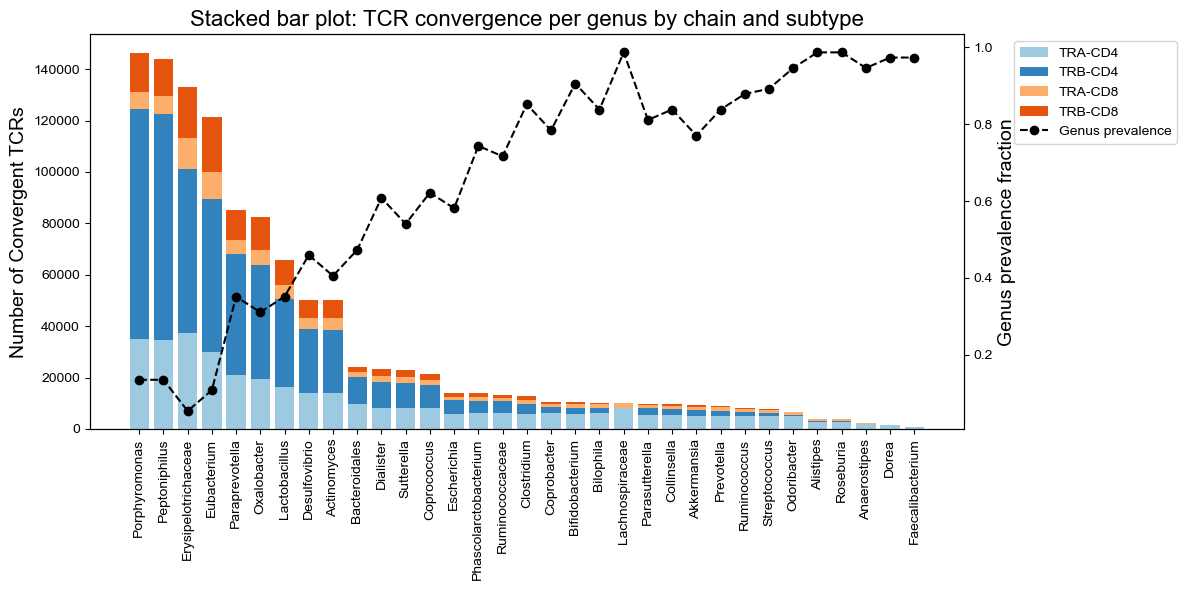

In [5]:
#########################
### Figure generation ###
#########################

custom_palette = {
    "TRA-CD4": "#9ecae1",
    "TRB-CD4": "#3182bd",
    "TRA-CD8": "#fdae6b",
    "TRB-CD8": "#e6550d",
}

convergence_df_sorted = convergence_df.sort_values("total_tcrs", ascending=False)
genus_labels = convergence_df_sorted["genus"]
x = range(len(genus_labels))

fig, ax1 = plt.subplots(figsize=(12, 6))

# Stacked bars
ax1.bar(
    x,
    convergence_df_sorted["TRA_CD4"],
    label="TRA-CD4",
    color=custom_palette["TRA-CD4"],
)
ax1.bar(
    x,
    convergence_df_sorted["TRB_CD4"],
    bottom=convergence_df_sorted["TRA_CD4"],
    label="TRB-CD4",
    color=custom_palette["TRB-CD4"],
)
ax1.bar(
    x,
    convergence_df_sorted["TRA_CD8"],
    bottom=convergence_df_sorted["TRA_CD4"] + convergence_df_sorted["TRB_CD4"],
    label="TRA-CD8",
    color=custom_palette["TRA-CD8"],
)
ax1.bar(
    x,
    convergence_df_sorted["TRB_CD8"],
    bottom=convergence_df_sorted["TRA_CD4"]
    + convergence_df_sorted["TRB_CD4"]
    + convergence_df_sorted["TRA_CD8"],
    label="TRB-CD8",
    color=custom_palette["TRB-CD8"],
)

ax1.set_ylabel("Number of Convergent TCRs", fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(genus_labels, rotation=90)

# Twin y-axis for genus prevalence
ax1b = ax1.twinx()
ax1b.plot(
    x,
    convergence_df_sorted["genus_prevalence"],
    "--o",
    color="black",
    label="Genus prevalence",
)
ax1b.set_ylabel("Genus prevalence fraction", fontsize=14)

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, bbox_to_anchor=(1.05, 1), loc=2)

plt.title(
    "Stacked bar plot: TCR convergence per genus by chain and subtype", fontsize=16
)
plt.tight_layout()
plt.savefig(figures_dir / "3A_convergence_prevalence.pdf", bbox_inches="tight")
plt.show()

### Figure 3C: TCR-microbiome interaction network

In [6]:
# Create the graph based on the nodes identified in network df
# Apply louvain community method to identify which nodes are more connected to each other than to the rest of the network
G = nx.Graph()
for a, b in zip(network_df["junction_aa"], network_df["genus"]):
    G.add_edge(a, b)

partition = community_louvain.best_partition(G)

# For readability, select on the top 20 largest communities and put everything else in a "Other" group
# Give each of the top 20 communities their own color
community_sizes = Counter(partition.values())
top_20_communities = {cid for cid, _ in community_sizes.most_common(20)}

partition_limited = {}
for node, cid in partition.items():
    if cid in top_20_communities:
        partition_limited[node] = cid
    else:
        partition_limited[node] = -1

num_colors = len(top_20_communities)
cmap = cm.get_cmap("tab20", num_colors)
community_id_to_color_index = {
    cid: i for i, cid in enumerate(sorted(top_20_communities))
}

community_colors = {}
for node, cid in partition_limited.items():
    if cid == -1:
        community_colors[node] = "#cccccc"
    else:
        rgb = cmap(community_id_to_color_index[cid])[:3]
        community_colors[node] = "#%02x%02x%02x" % tuple([int(255 * c) for c in rgb])

# Map nodes to communities
network_df["community"] = network_df["junction_aa"].map(partition_limited)
network_df["community"] = network_df["community"].replace({-1: "Other"})

# Degree dictionary for genus nodes
degree_dict = dict(G.degree())
genus_nodes = network_df["genus"].unique()
genus_degrees = {g: degree_dict[g] for g in genus_nodes if g in degree_dict}

# Sort and take top 3
top3_direct = sorted(genus_degrees.items(), key=lambda x: x[1], reverse=True)[:3]
print("Top 3 genus nodes by direct TCR connections:")
for genus, deg in top3_direct:
    print(genus, ":", deg, "TCRs")


two_step_counts = {}

for genus in genus_nodes:
    if genus not in G:
        continue
    tcr_neighbors = set(G.neighbors(genus))
    connected_genera = set()
    for tcr in tcr_neighbors:
        neighbors = set(G.neighbors(tcr))
        # Only count other genera, not TCRs
        connected_genera.update([n for n in neighbors if n in genus_nodes])
    connected_genera.discard(genus)
    two_step_counts[genus] = len(connected_genera)


# Sort and take top 3
top3_indirect = sorted(two_step_counts.items(), key=lambda x: x[1], reverse=True)[:3]
print("Top 3 genus nodes by indirect genus connections through TCRs:")
for genus, count in top3_indirect:
    print(genus, ":", count, "other genera")


community_values = list(partition.values())

num_communities = len(set(community_values))
print("Number of communities:", num_communities)

community_sizes = Counter(community_values)
for community_id, size in community_sizes.items():
    print(f"Community {community_id}: {size} nodes")

Top 3 genus nodes by direct TCR connections:
Lachnospiraceae : 493 TCRs
Erysipelotrichaceae : 432 TCRs
Odoribacter : 368 TCRs
Top 3 genus nodes by indirect genus connections through TCRs:
Erysipelotrichaceae : 23 other genera
Coprobacter : 21 other genera
Parasutterella : 21 other genera
Number of communities: 18
Community 1: 191 nodes
Community 15: 65 nodes
Community 11: 142 nodes
Community 5: 184 nodes
Community 2: 118 nodes
Community 9: 179 nodes
Community 16: 152 nodes
Community 12: 348 nodes
Community 14: 193 nodes
Community 17: 194 nodes
Community 3: 26 nodes
Community 4: 355 nodes
Community 8: 275 nodes
Community 6: 189 nodes
Community 7: 100 nodes
Community 10: 58 nodes
Community 13: 245 nodes
Community 0: 476 nodes


In [7]:
################################
### Create the Pyvis network ###
################################

pos = nx.spring_layout(G, seed=42)

net = Network(
    notebook=True,
    height="2000px",
    width="100%",
    select_menu=False,
    filter_menu=False,
    cdn_resources="remote",
    font_color="black",
)

for a, b, c, d, e in zip(
    network_df["node_id_var1"],
    network_df["junction_aa"],
    network_df["node_id_var2"],
    network_df["genus"],
    network_df["chain"],
):

    # Color the nodes by community
    tcr_color = community_colors[b] if b in community_colors else "#cccccc"
    genus_color = community_colors[d] if d in community_colors else "#cccccc"

    net.add_node(a, label="", color=tcr_color, shape="dot", size=50)
    net.add_node(c, label=d, color=genus_color, shape="box")
    net.add_edge(a, c, color="gray", physics=True)

genus_ids_dict = dict(zip(network_df["genus"], network_df["node_id_var2"]))
genus_ids = list(genus_ids_dict.values())
for n in net.nodes:
    if n["id"] in genus_ids:
        n["font"] = {"size": 120}

# Physics settings
net.barnes_hut(
    gravity=-80000,
    central_gravity=0,
    spring_length=400,
    spring_strength=0.05,
    damping=0.09,
    overlap=0,
)

net.show(str(figures_dir / "3C_network_community.html"))

/Users/romivandoren/Desktop/Romi/PhD/TCR_Microbiome/0_AIRRWAS_manuscript/X_git_repo/3_figures/Figures/3C_network_community.html


### Figure S2A: Publicity of convergent TCRs per convergence value

In [8]:
# Select only the TCRs that are significantly convergent (not residual TCRs)
conv_disc_base = combined_tail_df[
    (combined_tail_df["convergence"] > 2) & (combined_tail_df["pvalue"] <= 0.05)
]

# Calculate publicity based on vdj
conv_disc_base["full_tcr"] = (
    conv_disc_base["v_call"]
    + "_"
    + conv_disc_base["junction_aa"]
    + "_"
    + conv_disc_base["j_call"]
)
conv_disc_base["tcr_publicity"] = conv_disc_base.groupby("full_tcr")[
    "patient_id"
].transform("nunique")

conv_disc_base = conv_disc_base.drop_duplicates(
    subset=[
        "full_tcr",
        "genus",
        "convergence",
        "tcr_publicity",
    ]
)

# Create publicity bins
bins = [0, 1, 2, 3, 4, 5, np.inf]
labels = ["Private", "n=2", "n=3", "n=4", "n=5", "n>5"]
conv_disc_base["publicity_bin"] = pd.cut(
    conv_disc_base["tcr_publicity"], bins=bins, labels=labels, right=True
)

# One row per clonotype
clonotypes = (
    conv_disc_base[["full_tcr", "tcr_publicity", "publicity_bin"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Calculate various statistics about the publicity distribution
n_total = len(clonotypes)
n_private = (clonotypes["tcr_publicity"] == 1).sum()
n_public = (clonotypes["tcr_publicity"] > 1).sum()

pct_private = 100 * (n_private / n_total)
pct_public = 100 * (n_public / n_total)

max_publicity = clonotypes["tcr_publicity"].max()

n_ge3 = (clonotypes["tcr_publicity"] >= 3).sum()
pct_ge3 = 100 * (n_ge3 / n_total)
print(
    n_total, n_private, pct_private, n_public, pct_public, max_publicity, n_ge3, pct_ge3
)

# Exclude the private TCRs for the next plot
conv_disc_small = conv_disc_base[conv_disc_base["publicity_bin"] != "Private"]

642872 592960 92.23609054368521 49912 7.763909456314787 51 14164 2.203237969611369


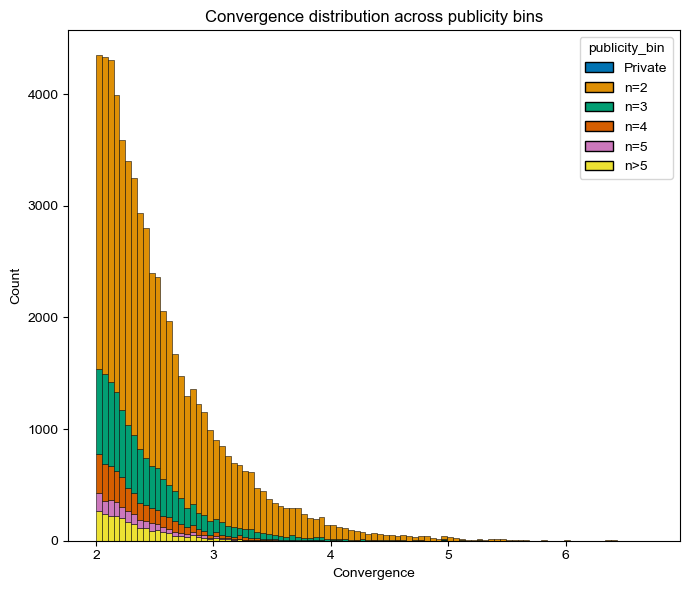

In [9]:
#########################
### Figure generation ###
#########################

plt.figure(figsize=(7, 6))

palette = sns.color_palette(
    ["#0173b2", "#de8f05", "#029e73", "#d55e00", "#cc78bc", "#ece133", "#56b4e9"],
    desat=1,
)

sns.histplot(
    data=conv_disc_small,
    x="convergence",
    hue="publicity_bin",
    multiple="stack",
    palette=palette,
    alpha=1,
    element="bars",
    edgecolor="black",
    binwidth=0.05,
)

plt.xlabel("Convergence")
plt.ylabel("Count")
plt.title("Convergence distribution across publicity bins")
plt.tight_layout()
plt.savefig(figures_dir / "S2A_convergence_publicity.pdf", bbox_inches="tight")
plt.show()

### Figure S2B: Total convergent TCRs vs genus prevalance and mean convergence

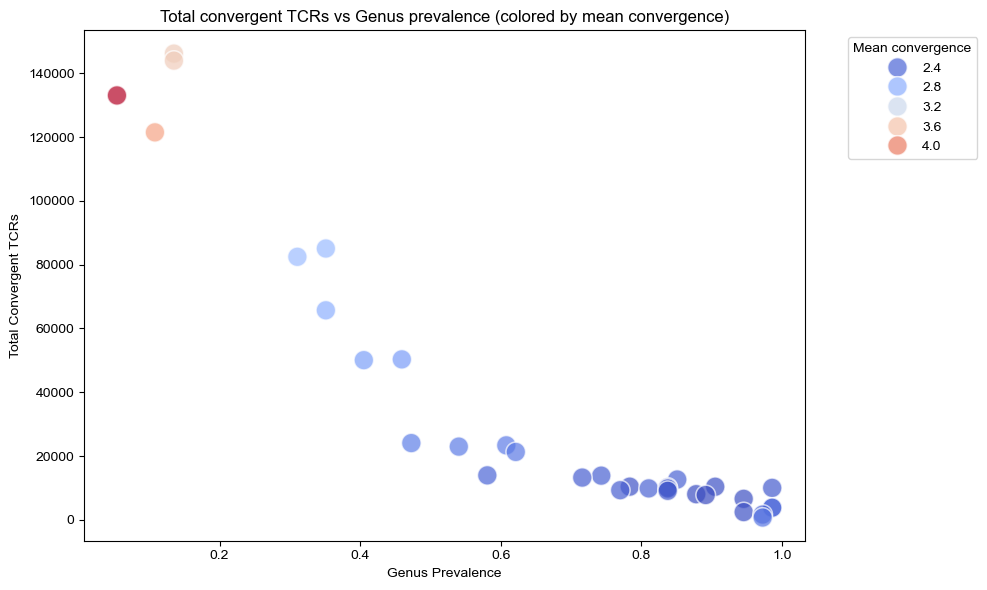

In [10]:
# Plot a scatterplot with one dot per genus, showing total convergent TCRs vs genus prevalence, colored by mean convergence
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=convergence_df,
    x="genus_prevalence",
    y="total_tcrs",
    s=200,
    hue="mean_convergence",
    palette="coolwarm",
    alpha=0.7,
)
plt.xlabel("Genus Prevalence")
plt.ylabel("Total Convergent TCRs")
plt.title("Total convergent TCRs vs Genus prevalence (colored by mean convergence)")
plt.legend(title="Mean convergence", bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.savefig(figures_dir / "S2B_convergence_prevalence.pdf", bbox_inches="tight")
plt.show()

### Figure 4A+B: Covariate correction effects, inlcuding shift and varaince explained

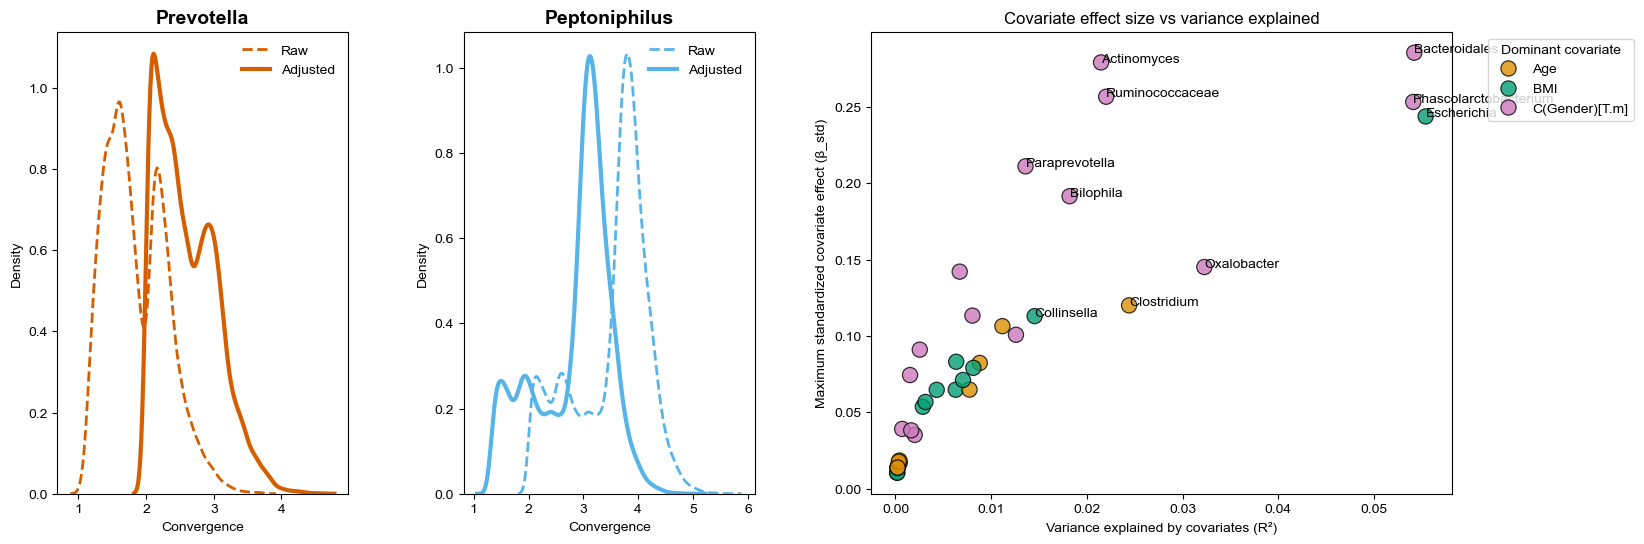

In [11]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    gridspec_kw={"width_ratios": [1, 1, 2], "wspace": 0.3},
    sharey=False,
)


# Figure 4A: Faceted KDE for genera Prevotella and Peptoniphilus
key_genera = ["Prevotella", "Peptoniphilus"]
colors = ["#d55e00", "#56b4e9"]

for ax, genus, color in zip(axes[:2], key_genera, colors):
    gdf = combined_tail_df[combined_tail_df["genus"] == genus]

    sns.kdeplot(
        gdf["convergence"], ax=ax, color=color, lw=2, linestyle="--", label="Raw"
    )
    sns.kdeplot(gdf["conv_residual"], ax=ax, color=color, lw=3, label="Adjusted")

    ax.set_title(f"{genus}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Convergence")
    if ax == axes[0]:
        ax.set_ylabel("Density")
    ax.legend(frameon=False)


# Figure 4B: Scatterplot max effect vs R²
covariate_cols = ["Age", "BMI"] + [
    c for c in covariate_effects_df.columns if c.startswith("C(")
]
covariate_effects_df[covariate_cols] = covariate_effects_df[covariate_cols].apply(
    pd.to_numeric, errors="coerce"
)

# Compute max effect and dominant covariate per genus
covariate_effects_df["max_effect"] = (
    covariate_effects_df[covariate_cols].abs().max(axis=1)
)
covariate_effects_df["dominant_covariate"] = (
    covariate_effects_df[covariate_cols].abs().idxmax(axis=1)
)

ax = axes[2]
sns.scatterplot(
    data=covariate_effects_df,
    x="R2",
    y="max_effect",
    hue="dominant_covariate",
    palette=["#de8f05", "#029e73", "#cc78bc"],
    s=120,
    edgecolor="k",
    alpha=0.8,
    ax=ax,
)

# Annotate top genera by R²
top5 = covariate_effects_df.nlargest(10, "R2")
texts = []
for _, row in top5.iterrows():
    texts.append(ax.text(row["R2"], row["max_effect"], row["genus"], fontsize=10))

ax.set_xlabel("Variance explained by covariates (R²)")
ax.set_ylabel("Maximum standardized covariate effect (β_std)")
ax.set_title("Covariate effect size vs variance explained")

ax.legend(title="Dominant covariate", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(figures_dir / "4_covariate_correction.pdf", bbox_inches="tight")
plt.show()

### Figure S3A: Convergence shifts for all genera

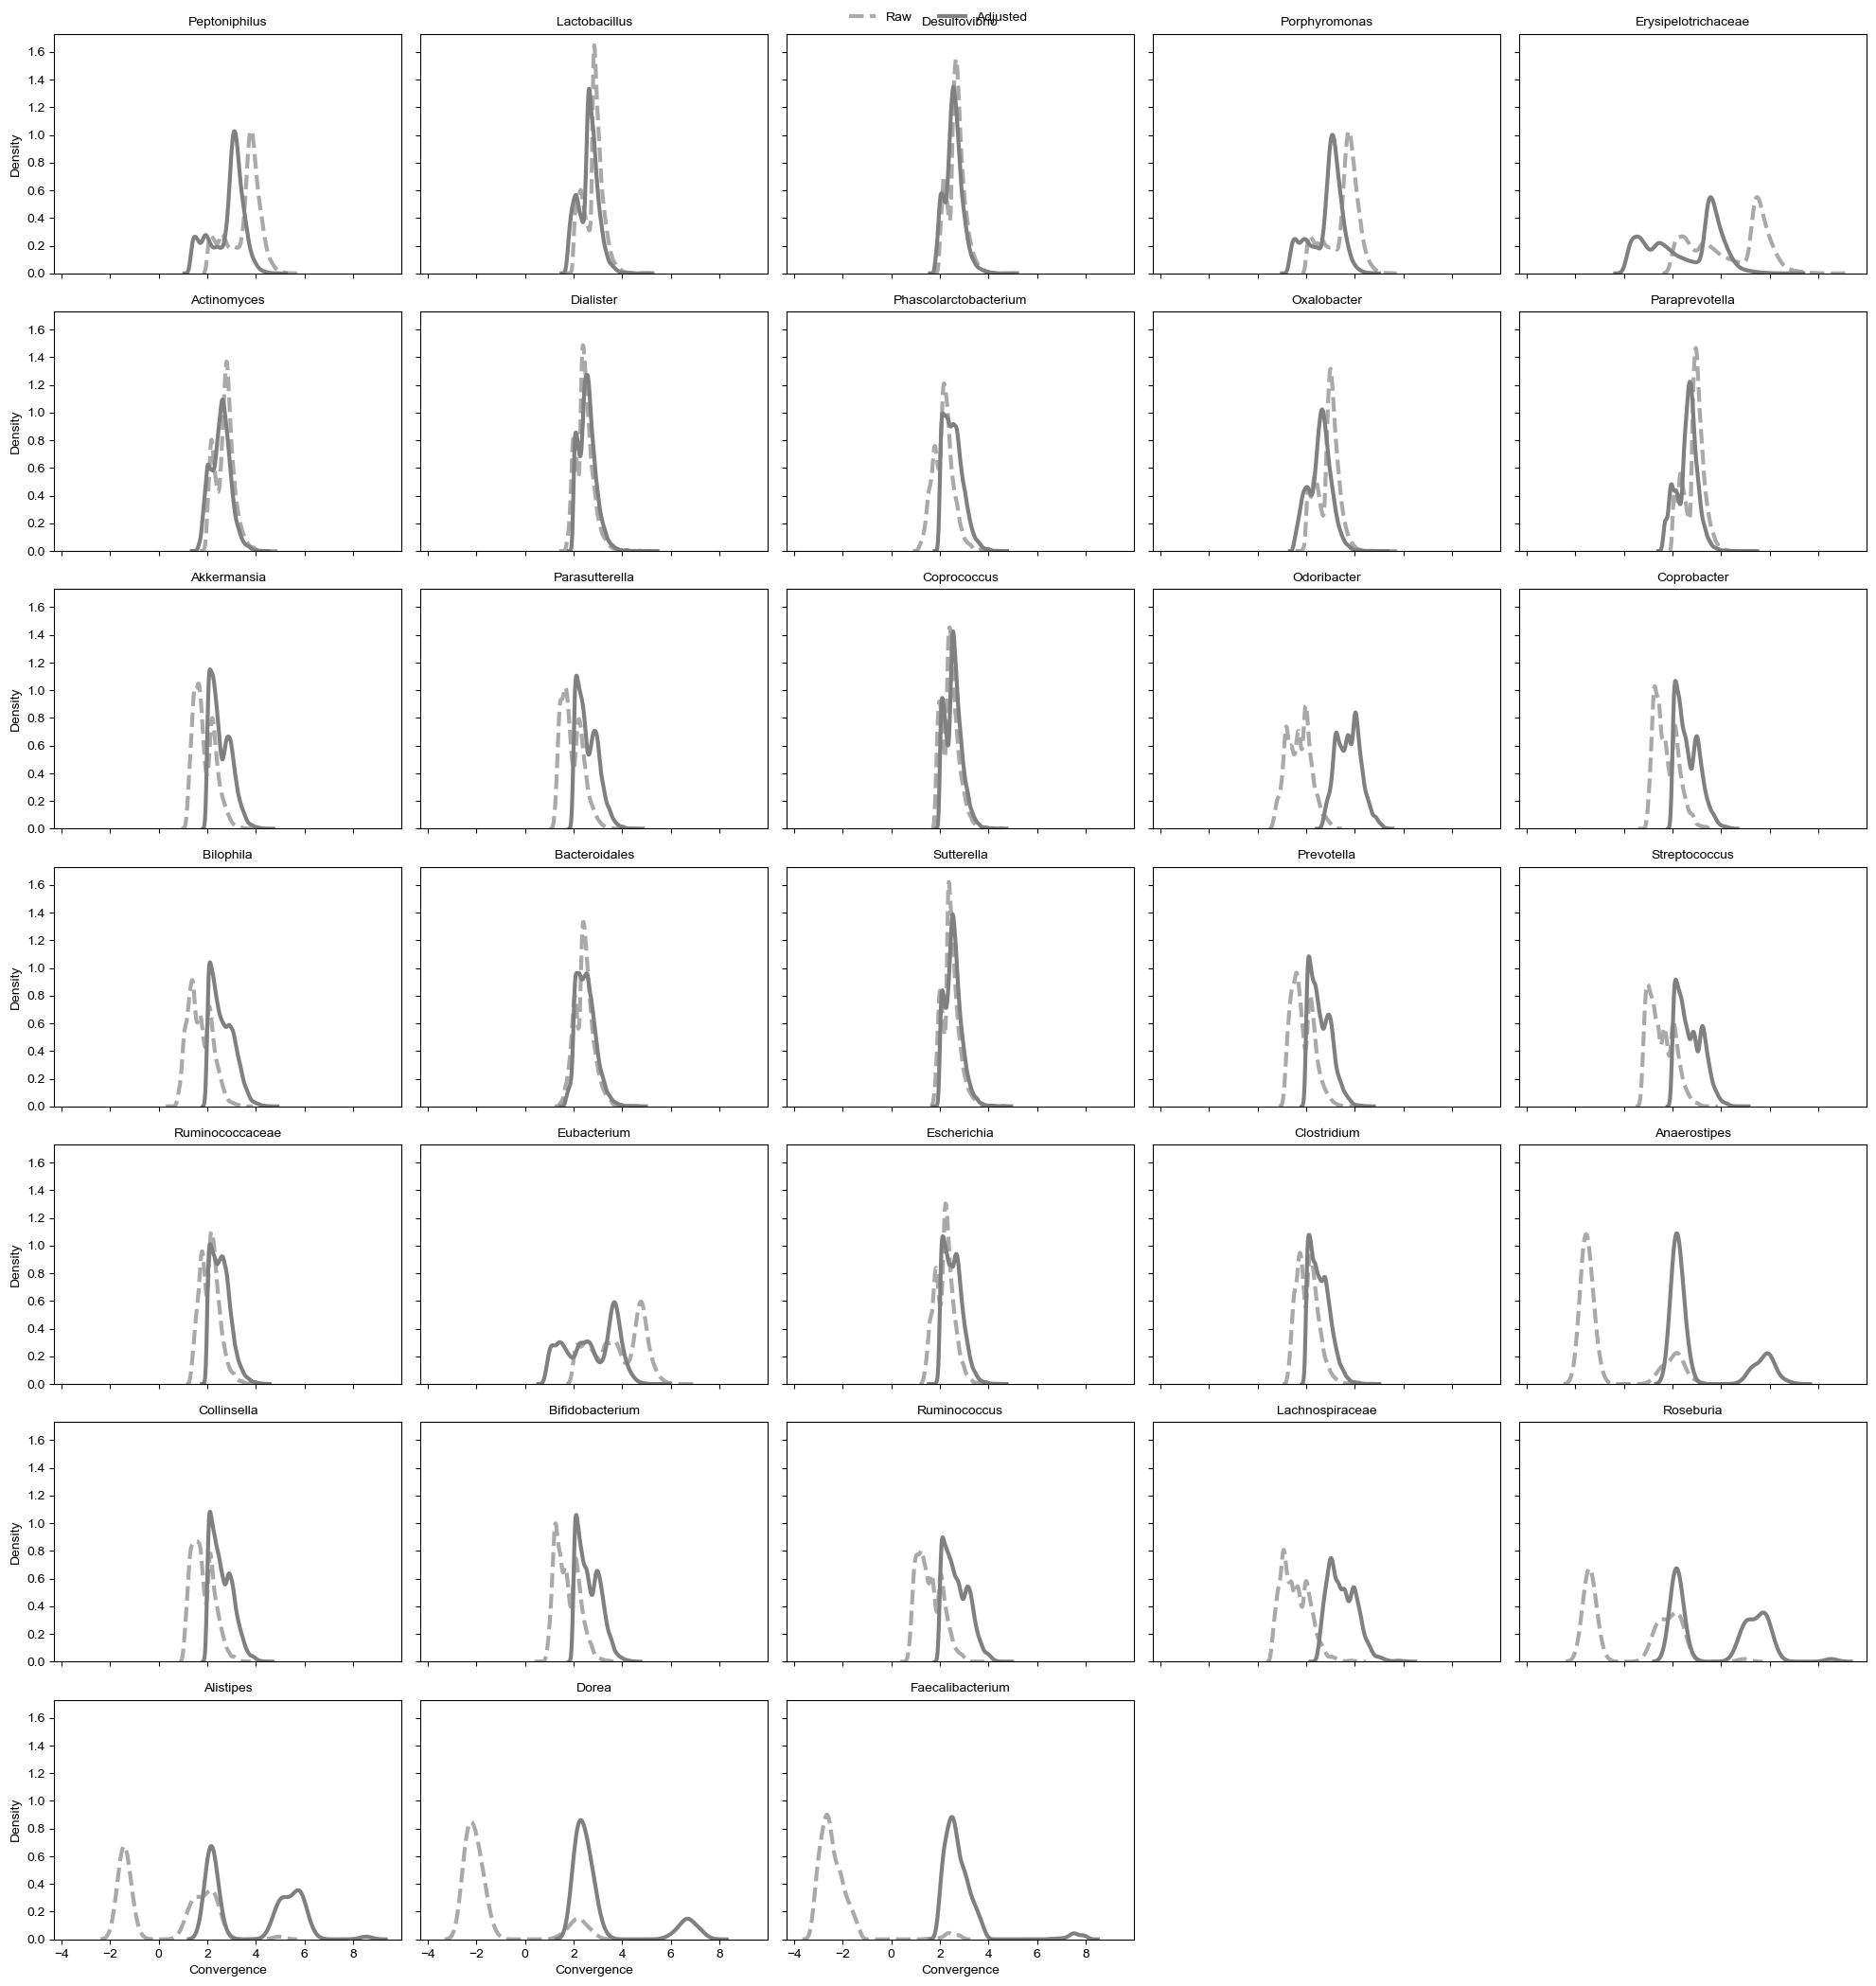

In [12]:
ncols = 5
nrows = math.ceil(len(sorted_genera) / ncols)

fig, axes = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True, sharey=True
)

axes = axes.flatten()

for ax, genus in zip(axes, sorted_genera):

    gdf = combined_tail_df[combined_tail_df["genus"] == genus]

    # Raw convergence
    sns.kdeplot(
        gdf["convergence"], ax=ax, color="darkgrey", lw=3, linestyle="--", label="Raw"
    )

    # Residual convergence
    sns.kdeplot(
        gdf["conv_residual"], ax=ax, color="grey", lw=3, linestyle="-", label="Adjusted"
    )

    ax.set_title(genus, fontsize=10)
    ax.set_xlabel("Convergence")
    ax.set_ylabel("Density")

# remove empty panels
for ax in axes[len(sorted_genera) :]:
    ax.remove()

# single legend for whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

plt.tight_layout()
plt.savefig(figures_dir / "S3A_convergence_shifts_all_genera.pdf", bbox_inches="tight")
plt.show()

### Figure S3B: Effect sizes of covariates

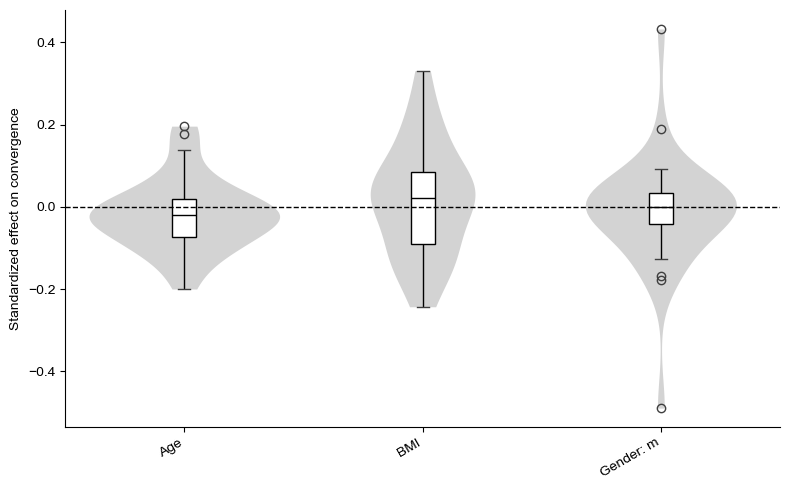

In [13]:
plot_results = []


# Extract covariate effects from the regression models for each genus and standardize them
for genus, df in combined_tail_df.groupby("genus"):
    df = df.dropna(subset=["convergence", "Age", "BMI", "Gender"])
    model = smf.ols("convergence ~ Age + BMI + C(Gender)", data=df).fit()
    y_sd = df["convergence"].std()

    for var in ["Age", "BMI"]:
        beta = model.params[var]
        beta_std = beta * df[var].std() / y_sd
        plot_results.append({"genus": genus, "covariate": var, "beta_std": beta_std})

    for var in model.params.index:
        if var.startswith("C("):
            plot_results.append(
                {"genus": genus, "covariate": var, "beta_std": model.params[var]}
            )

plot_df = pd.DataFrame(plot_results)

# Clean covariate names
plot_df["covariate"] = plot_df["covariate"].str.replace(
    "C\\(Gender\\)\\[T\\.", "Gender: ", regex=True
)
plot_df["covariate"] = plot_df["covariate"].str.replace("\\]", "", regex=True)


#########################
### Figure generation ###
#########################

fig, ax = plt.subplots(figsize=(8, 5))

sns.violinplot(
    data=plot_df,
    x="covariate",
    y="beta_std",
    color="lightgrey",
    inner=None,
    linewidth=0,
    cut=0,
    ax=ax,
)

sns.boxplot(
    data=plot_df,
    x="covariate",
    y="beta_std",
    width=0.1,
    showcaps=True,
    boxprops={"facecolor": "white", "edgecolor": "black"},
    medianprops={"color": "black"},
    whiskerprops={"color": "black"},
    ax=ax,
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("")
ax.set_ylabel("Standardized effect on convergence")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

sns.despine()
plt.tight_layout()
plt.savefig(figures_dir / "S3B_violin_plot_covariate_effects.pdf", bbox_inches="tight")
plt.show()

# Cross-cohort convergence overview

In [14]:
# Identify the clustered convergent TCRs and identify shared clusters among the three dataset
results = analyze_clusters(
    genera=sorted_genera,
    cluster_dir=base_dir / "2_processed_data" / "7_cluster_convergence",
    output_dir=base_dir / "2_processed_data" / "6_combined_convergence",
    convergence_threshold=2,
    pvalue_threshold=0.05,
    top_percentile=10,
)

### Figure 5: Prevotella and peptoniphilus shared clusters

In [15]:
# Select genera of interest
genera_main = ["Prevotella", "Peptoniphilus"]

# Map genus -> index in sorted_genera
genus_to_index = {g: sorted_genera.index(g) for g in genera_main}

prev_idx = genus_to_index["Prevotella"]
pept_idx = genus_to_index["Peptoniphilus"]

df_prev = results["grouped"][prev_idx].copy()
df_pept = results["grouped"][pept_idx].copy()

p_prev = results["adjusted_pval"][prev_idx]
p_pept = results["adjusted_pval"][pept_idx]

# Select only the genera with shared clusters
valid_indices = [
    i
    for i, df_grouped in enumerate(results["grouped"])
    if df_grouped is not None
    and not df_grouped.empty
    and "red" in df_grouped["color_sharing"].values
]

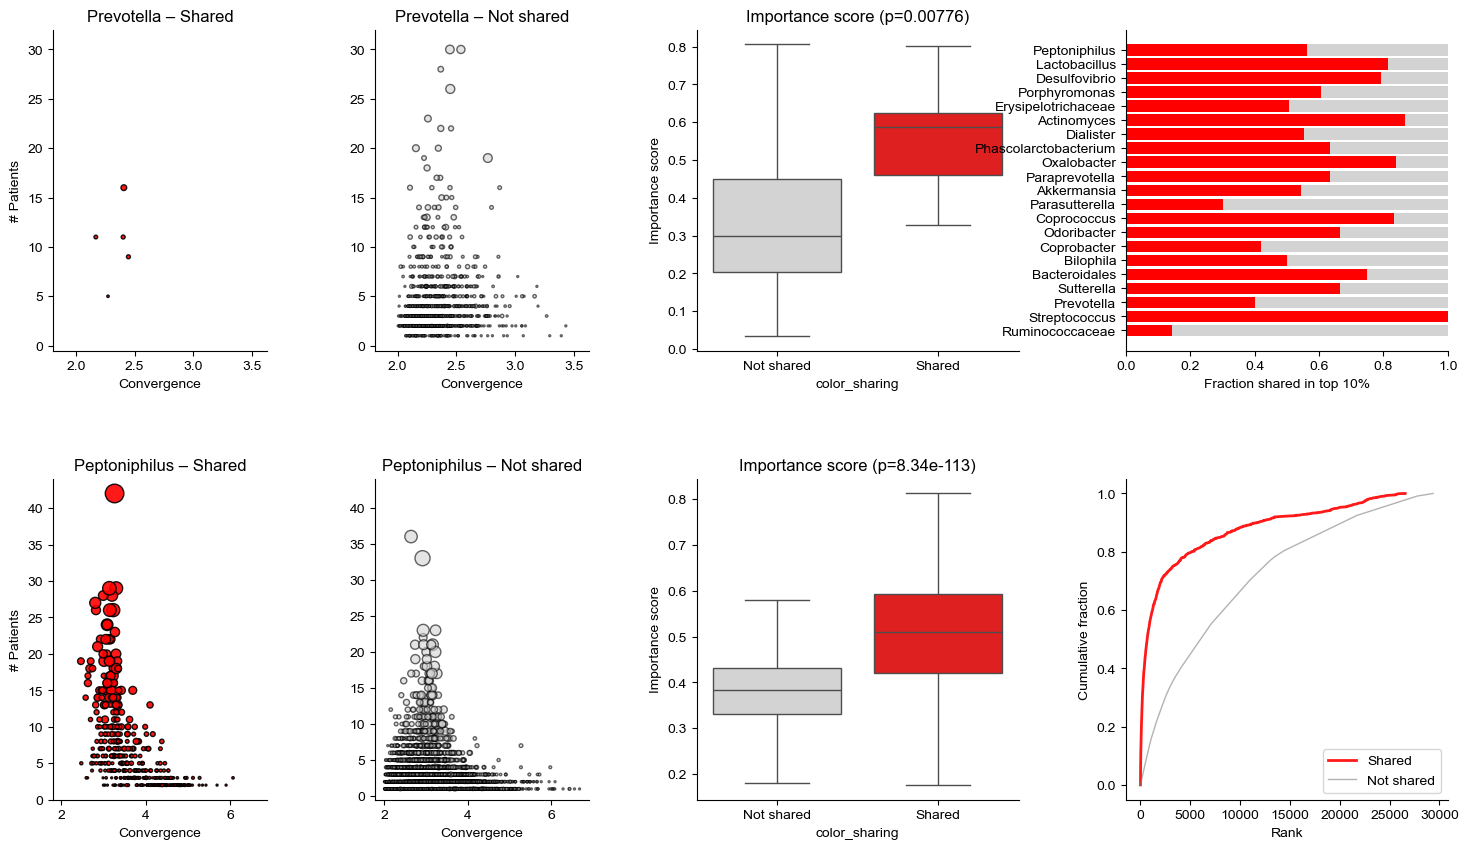

In [16]:
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 4, wspace=0.4, hspace=0.4, width_ratios=[1, 1, 1.5, 1.5])


# ROW 1: Prevotella


# Scatter SHARED
ax1 = fig.add_subplot(gs[0, 0])
shared_prev = df_prev[df_prev["color_sharing"] == "red"]

ax1.scatter(
    shared_prev["mean_convergence"],
    shared_prev["unique_patients"],
    s=shared_prev["cluster_size"],
    c="red",
    edgecolors="k",
    alpha=0.9,
    rasterized=True,
)
ax1.set_title("Prevotella – Shared")
ax1.set_xlabel("Convergence")
ax1.set_ylabel("# Patients")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)


# Scatter NON-SHARED
ax2 = fig.add_subplot(gs[0, 1])
grey_prev = df_prev[df_prev["color_sharing"] != "red"]

ax2.scatter(
    grey_prev["mean_convergence"],
    grey_prev["unique_patients"],
    s=grey_prev["cluster_size"],
    c="lightgrey",
    edgecolors="k",
    alpha=0.6,
    rasterized=True,
)
ax2.set_title("Prevotella – Not shared")
ax2.set_xlabel("Convergence")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

xmin_prev = df_prev["mean_convergence"].min()
xmax_prev = df_prev["mean_convergence"].max()
ymin_prev = df_prev["unique_patients"].min()
ymax_prev = df_prev["unique_patients"].max()

ax1.set_xlim(xmin_prev - 0.2, xmax_prev + 0.2)
ax2.set_xlim(xmin_prev - 0.2, xmax_prev + 0.2)
ax1.set_ylim(-0.5, ymax_prev + 2)
ax2.set_ylim(-0.5, ymax_prev + 2)


# Boxplot
ax3 = fig.add_subplot(gs[0, 2])

sns.boxplot(
    data=df_prev,
    x="color_sharing",
    y="topright_score",
    palette={"red": "red", "lightgrey": "lightgrey"},
    showfliers=False,
    ax=ax3,
)

ax3.set_xticklabels(["Not shared", "Shared"])
ax3.set_title(f"Importance score (p={p_prev:.3g})")
ax3.set_ylabel("Importance score")
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)


# FULL Barplot
ax4 = fig.add_subplot(gs[0, 3])

summary_df = results["summary_frac"]
valid_genera = [sorted_genera[i] for i in valid_indices]
summary_df = summary_df[summary_df["Genus"].isin(valid_genera)].copy()
summary_df["FractionTop"] = summary_df["FractionTop"].fillna(0)
summary_df["FractionGrey"] = 1 - summary_df["FractionTop"]

summary_df["Genus"] = pd.Categorical(
    summary_df["Genus"], categories=valid_genera[::-1], ordered=True
)
summary_df.sort_values("Genus", inplace=True)

ax4.barh(summary_df["Genus"], summary_df["FractionTop"], color="red")
ax4.barh(
    summary_df["Genus"],
    summary_df["FractionGrey"],
    left=summary_df["FractionTop"],
    color="lightgrey",
)

ax4.set_xlim(0, 1)
ax4.set_xlabel("Fraction shared in top 10%")
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)


# ROW 2: Peptoniphilus

# Scatter SHARED
ax5 = fig.add_subplot(gs[1, 0])
shared_pept = df_pept[df_pept["color_sharing"] == "red"]

ax5.scatter(
    shared_pept["mean_convergence"],
    shared_pept["unique_patients"],
    s=shared_pept["cluster_size"],
    c="red",
    edgecolors="k",
    alpha=0.9,
    rasterized=True,
)
ax5.set_title("Peptoniphilus – Shared")
ax5.set_xlabel("Convergence")
ax5.set_ylabel("# Patients")
ax5.spines["top"].set_visible(False)
ax5.spines["right"].set_visible(False)


# Scatter NON-SHARED
ax6 = fig.add_subplot(gs[1, 1])
grey_pept = df_pept[df_pept["color_sharing"] != "red"]

ax6.scatter(
    grey_pept["mean_convergence"],
    grey_pept["unique_patients"],
    s=grey_pept["cluster_size"],
    c="lightgrey",
    edgecolors="k",
    alpha=0.6,
    rasterized=True,
)
ax6.set_title("Peptoniphilus – Not shared")
ax6.set_xlabel("Convergence")
ax6.spines["top"].set_visible(False)
ax6.spines["right"].set_visible(False)


xmin_pept = df_pept["mean_convergence"].min()
xmax_pept = df_pept["mean_convergence"].max()
ymin_pept = df_pept["unique_patients"].min()
ymax_pept = df_pept["unique_patients"].max()

ax5.set_xlim(xmin_pept - 0.2, xmax_pept + 0.2)
ax5.set_xlim(xmin_pept - 0.2, xmax_pept + 0.2)
ax6.set_ylim(-0.5, ymax_pept + 2)
ax6.set_ylim(-0.5, ymax_pept + 2)

# Boxplot
ax7 = fig.add_subplot(gs[1, 2])

sns.boxplot(
    data=df_pept,
    x="color_sharing",
    y="topright_score",
    palette={"red": "red", "lightgrey": "lightgrey"},
    showfliers=False,
    ax=ax7,
)

ax7.set_xticklabels(["Not shared", "Shared"])
ax7.set_title(f"Importance score (p={p_pept:.3g})")
ax7.set_ylabel("Importance score")
ax7.spines["top"].set_visible(False)
ax7.spines["right"].set_visible(False)


# FULL ECDF
ax8 = fig.add_subplot(gs[1, 3])

all_ranks_df = results["all_ranks"]

for color, label, cond in [
    ("red", "Shared", all_ranks_df["is_red"]),
    ("grey", "Not shared", ~all_ranks_df["is_red"]),
]:
    ranks = np.sort(all_ranks_df.loc[cond, "rank"])
    if len(ranks) > 0:
        y_vals = np.arange(1, len(ranks) + 1) / len(ranks)

        ax8.plot(
            ranks,
            y_vals,
            color=color,
            label=label,
            linewidth=2 if color == "red" else 1,
            alpha=0.9 if color == "red" else 0.6,
        )

ax8.set_xlabel("Rank")
ax8.set_ylabel("Cumulative fraction")
ax8.legend()
ax8.spines["top"].set_visible(False)
ax8.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(figures_dir / "5_Prev_Pept_shared_clusters.pdf", bbox_inches="tight")
plt.show()

### Figure S4: Dotplots and boxplots for shared clusters in all genera

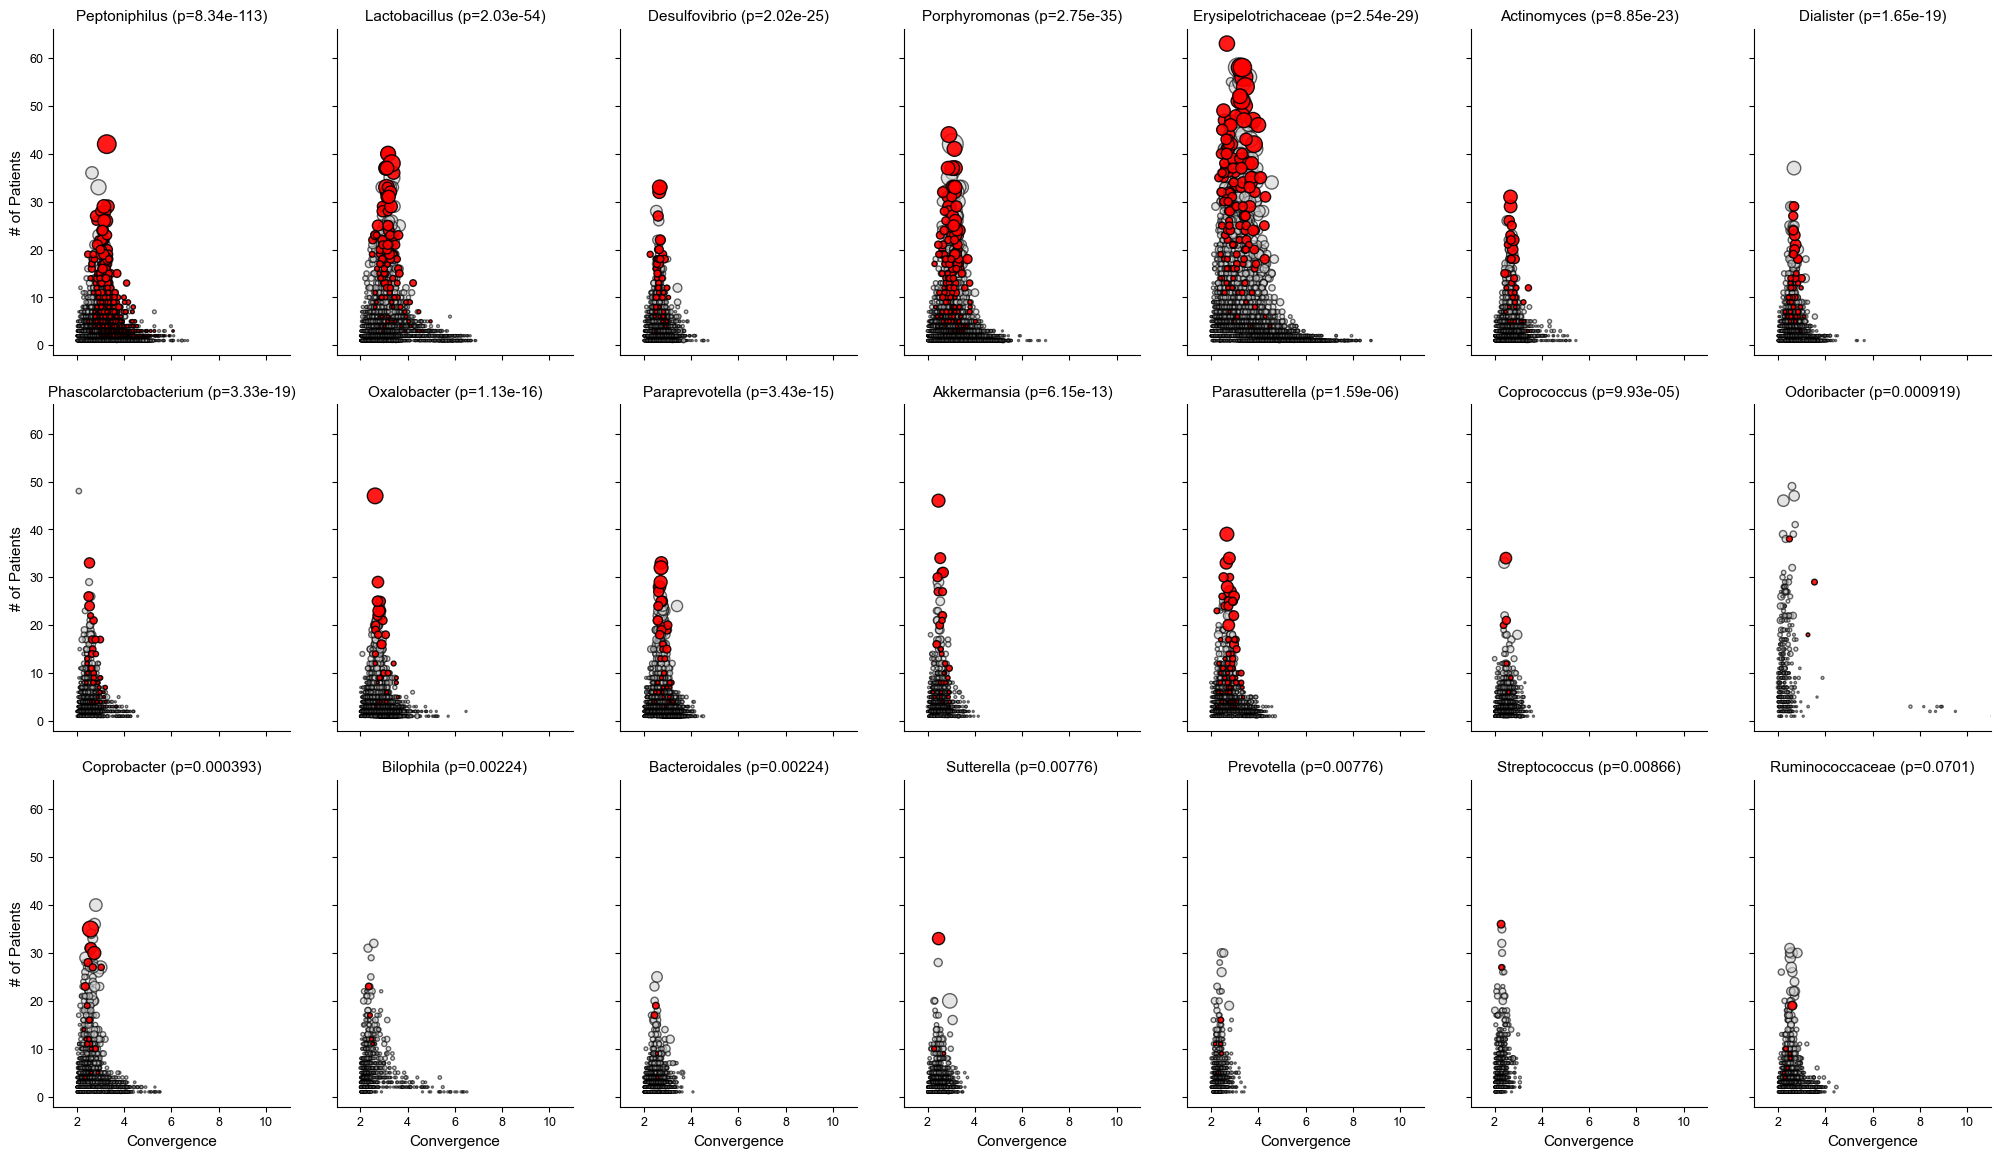

In [17]:
### Global settings #####
figsize = (25, 14)
font_size = 11
marker_alpha = {"red": 0.9, "lightgrey": 0.6}
line_width = {"red": 2, "grey": 1}
scatter_xlim = (1, 11)
scatter_marker_edge = "k"

hspace_main = 0.5
wspace_main = 0.3
hspace_scatter = 0.15
wspace_scatter = 0.2

plt.rcParams.update(
    {
        "axes.titlesize": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": font_size,
    }
)

#########################
### Create Figure #######
#########################

fig = plt.figure(figsize=figsize)
gs = fig.add_gridspec(
    6,
    7,
    width_ratios=[1, 1, 1, 1, 1, 1, 1],
    height_ratios=[1] * 6,
    hspace=hspace_main,
    wspace=wspace_main,
)


### Panel 1: Scatterplots ###
scatter_gs = gs[:, 0:7].subgridspec(3, 7, hspace=hspace_scatter, wspace=wspace_scatter)
scatter_axes = scatter_gs.subplots(sharex=True, sharey=True).flatten()

for ax, i in zip(scatter_axes, valid_indices):
    df_grouped = results["grouped"][i]
    for color in ["lightgrey", "red"]:
        subset = df_grouped[df_grouped["color_sharing"] == color]
        if not subset.empty:
            ax.scatter(
                subset["mean_convergence"],
                subset["unique_patients"],
                s=subset["cluster_size"],
                c=color,
                edgecolors=scatter_marker_edge,
                alpha=marker_alpha[color],
                rasterized=True,
            )
    ax.set_xlim(*scatter_xlim)

    pval = results["adjusted_pval"][i]
    title = (
        f"{sorted_genera[i]} (p={pval:.3g})"
        if not np.isnan(pval)
        else f"{sorted_genera[i]} (p=.)"
    )
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in scatter_axes[::7]:
    ax.set_ylabel("# of Patients")

for ax in scatter_axes[-7:]:
    ax.set_xlabel("Convergence")


plt.tight_layout()
plt.savefig(
    figures_dir / "S4A_Prev_Pept_dotplot_shared_clusters.pdf", bbox_inches="tight"
)
plt.show()

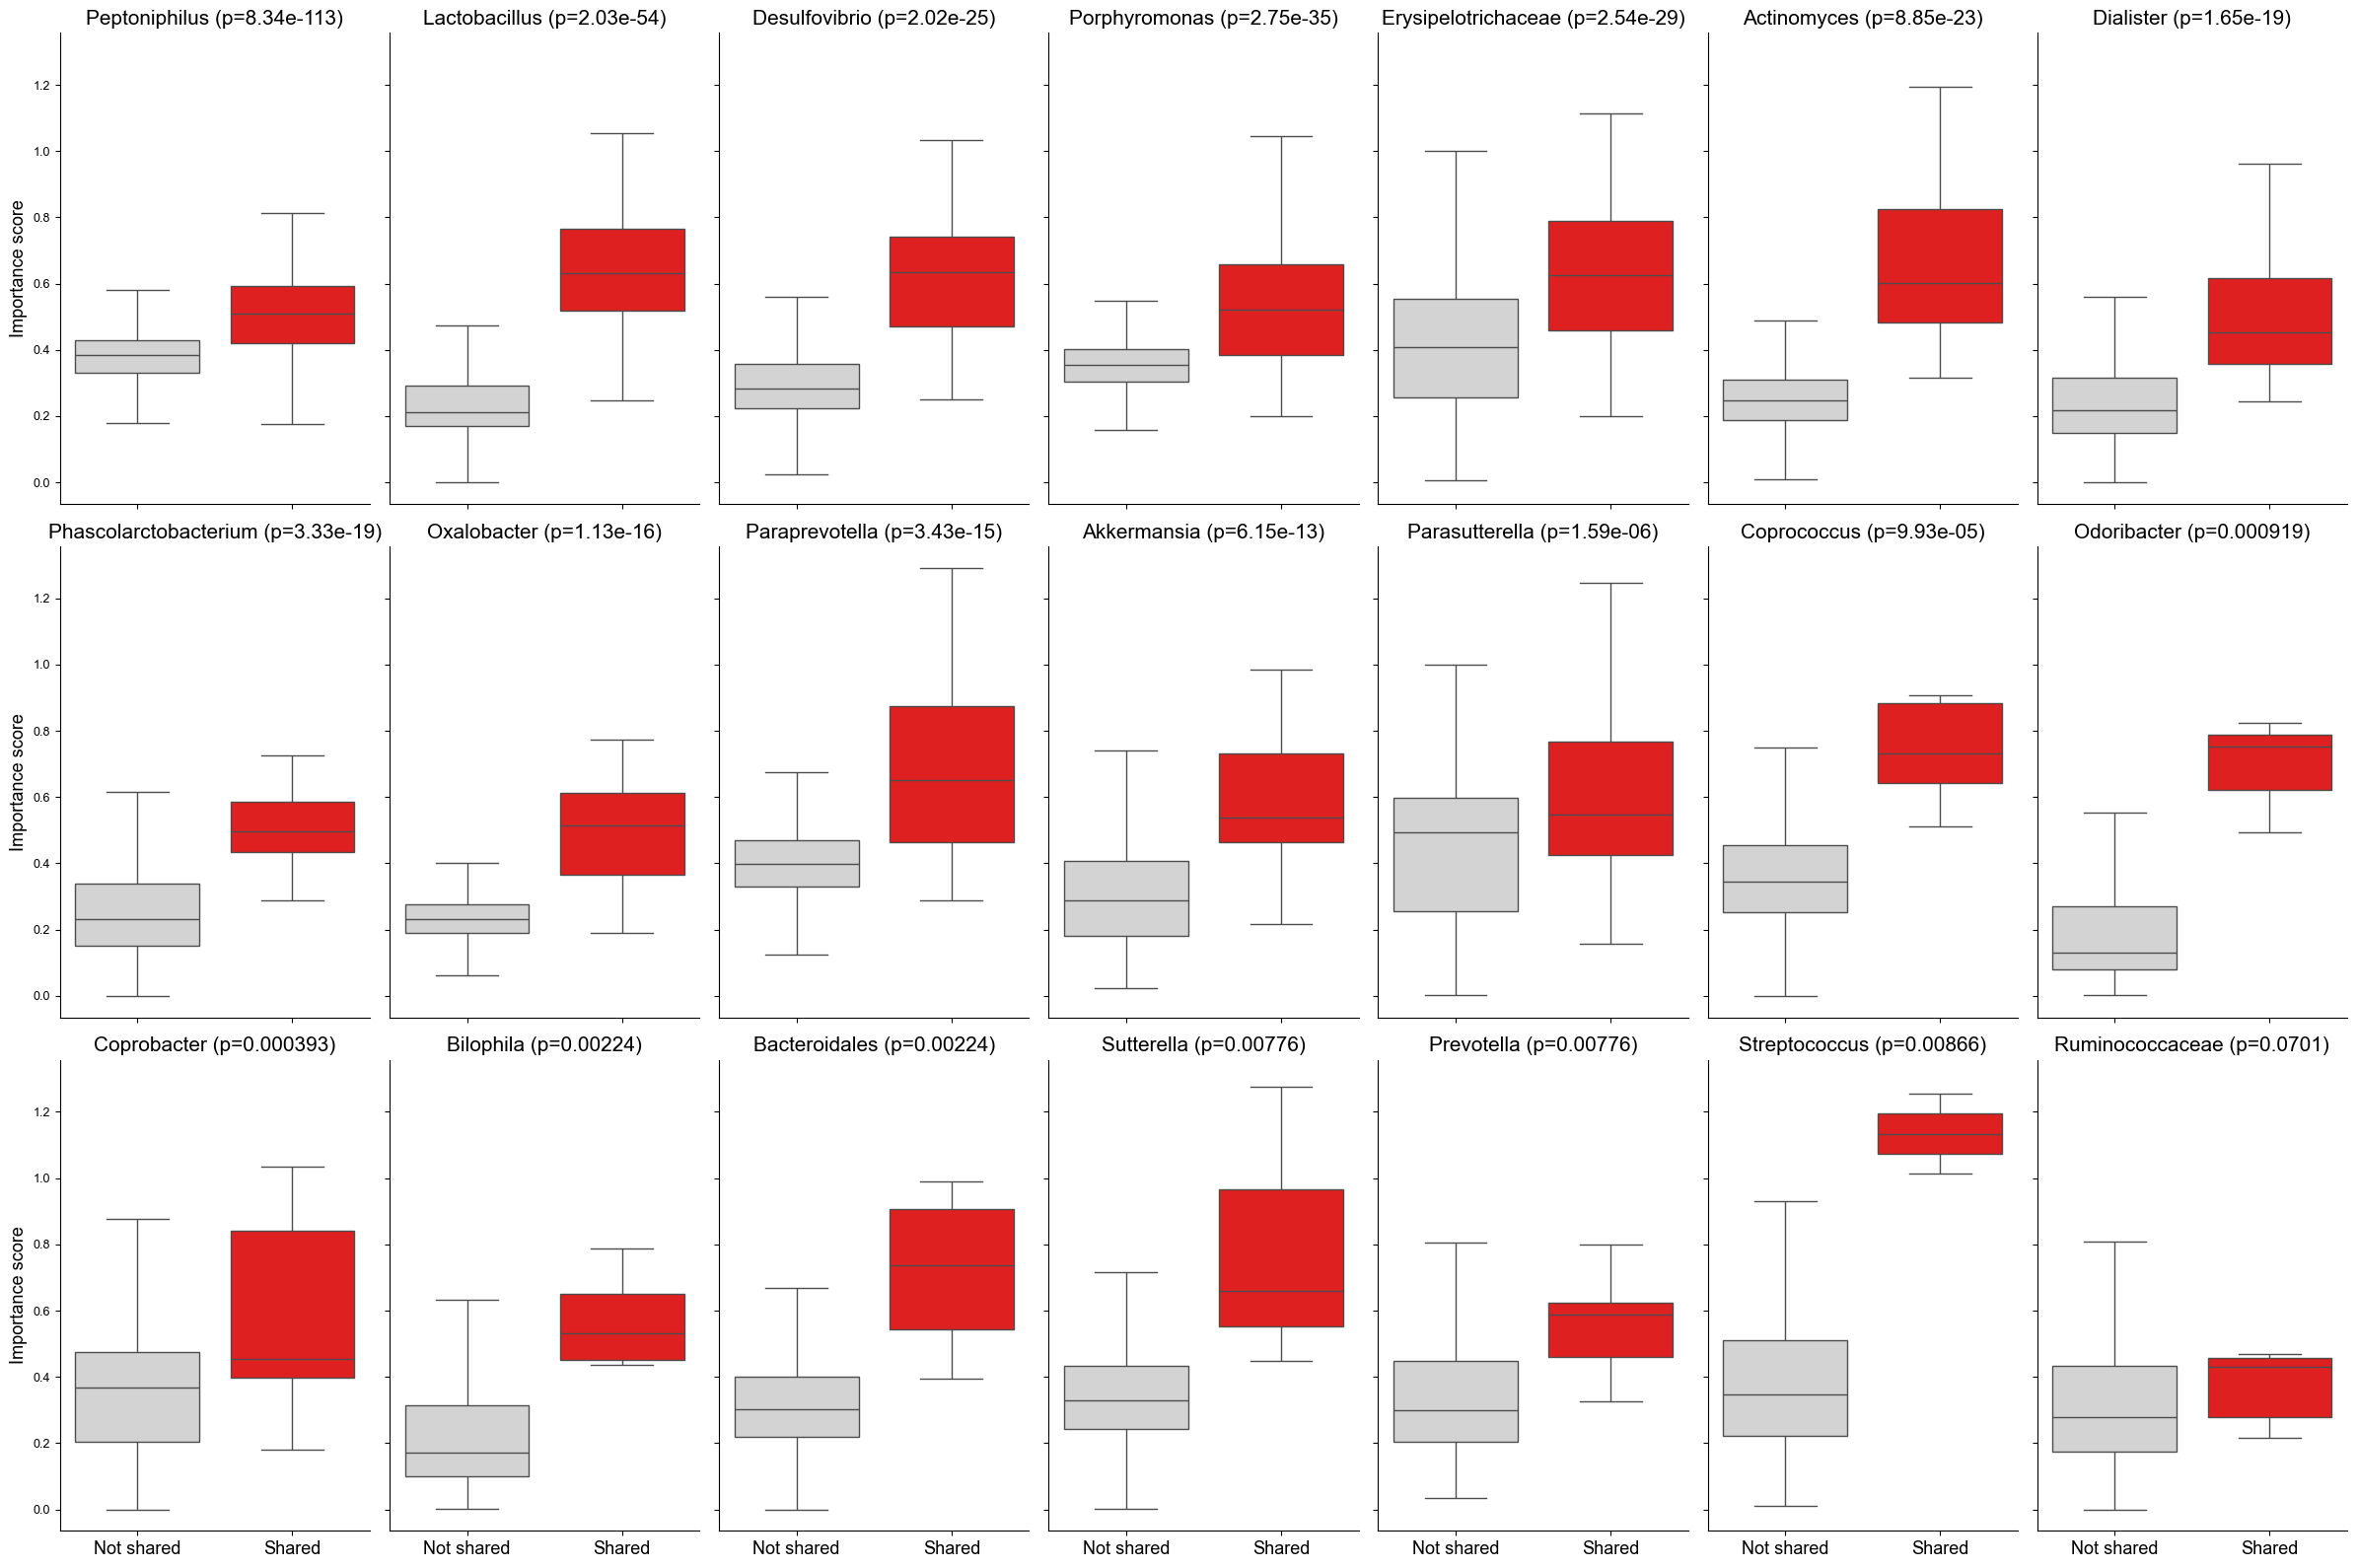

In [18]:
n_valid = len(results["grouped"])
n_rows, n_cols = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 16), sharex=True, sharey=True)
axes = axes.flatten()

valid_genera = [sorted_genera[i] for i in valid_indices]

for i, (genus, df_grouped, pval) in enumerate(
    zip(valid_genera, results["grouped"], results["adjusted_pval"])
):
    ax = axes[i]

    # Boxplot + stripplot
    sns.boxplot(
        data=df_grouped,
        x="color_sharing",
        y="topright_score",
        palette={"red": "red", "lightgrey": "lightgrey"},
        showfliers=False,
        ax=ax,
    )

    ax.set_xticklabels(["Not shared", "Shared"], size=13)
    ax.set_title(
        f"{genus} (p={pval:.3g})" if not np.isnan(pval) else f"{genus} (p=.)", size=15
    )
    ax.set_ylabel("Importance score" if i % n_cols == 0 else "", size=13)
    ax.set_xlabel("")

    # Remove top/right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Hide unused axes
for j in range(n_valid, n_rows * n_cols):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.savefig(
    figures_dir / "S4B_Prev_Pept_boxplot_shared_clusters.pdf", bbox_inches="tight"
)
plt.show()

# Cell type distribution

### Figures S5-7: per patient cell types across three datasets

In [19]:
subset_dir = base_dir / "2_processed_data" / "8_T_cell_subsets"

#  Discovery data
full_tcr_disc = pd.read_csv(
    subset_dir / "1_full_info_disc_data.csv", index_col=0
).rename(columns={"erc_cell": "cell_type"})
before_df_disc = pd.read_csv(subset_dir / "1_before_disc_data.csv", index_col=0).rename(
    columns={"erc_cell": "cell_type"}
)

# CRC data
full_tcr_pu = pd.read_csv(subset_dir / "2_full_info_Pu_data.csv", index_col=0)
before_df_pu = pd.read_csv(subset_dir / "2_before_Pu_data.csv", index_col=0)

# IBD data
full_tcr_brand = pd.read_csv(subset_dir / "3_full_info_Brand_data.csv", index_col=0)
before_df_brand = pd.read_csv(subset_dir / "3_before_Brand_data.csv", index_col=0)

In [20]:
keys = ["junction", "junction_aa", "v_call", "j_call", "patient_id", "cell_type"]

sorted_genera = [
    "Peptoniphilus",
    "Lactobacillus",
    "Desulfovibrio",
    "Porphyromonas",
    "Erysipelotrichaceae",
    "Actinomyces",
    "Dialister",
    "Phascolarctobacterium",
    "Oxalobacter",
    "Paraprevotella",
    "Akkermansia",
    "Parasutterella",
    "Coprococcus",
    "Odoribacter",
    "Coprobacter",
    "Bilophila",
    "Bacteroidales",
    "Sutterella",
    "Prevotella",
    "Streptococcus",
    "Ruminococcaceae",
]

In [21]:
# Define datasets
datasets = [
    ("Dataset A", full_tcr_disc, before_df_disc),
    ("Dataset B", full_tcr_pu, before_df_pu),
    ("Dataset C", full_tcr_brand, before_df_brand),
]

keys = ["junction", "junction_aa", "v_call", "j_call", "patient_id", "cell_type"]

# Apply cell type distribution calculation for each dataset and concatenate results
res_list = []
for name, full_df, before_df in datasets:
    df_patient = patient_celltype_distribution(
        full_df, before_df, keys, sorted_genera, name
    )
    res_list.append(df_patient)

res_df_all = pd.concat(res_list, ignore_index=True)


# Pivot table for visualization
heatmap = res_df_all.pivot_table(
    index=["dataset", "patient_id", "cell_type"],
    columns="genus",
    values="Log2FC",
    aggfunc="mean",
)

heatmap = heatmap.reindex(columns=sorted_genera)
heatmap = heatmap.fillna(0)

print("Patient-level overview ready!")
heatmap.head()

Patient-level overview ready!


genus                           Peptoniphilus  Lactobacillus  Desulfovibrio  \
dataset   patient_id cell_type                                                
Dataset A CO003      CD4            -0.135733       0.449229       0.378840   
                     CD8             0.149842      -0.850158      -0.657513   
          CO037      CD4            -0.156834      -0.086481      -0.760906   
                     CD8             0.652117       0.403582       1.711011   
          CO038      CD4            -0.002531      -0.011835      -0.097481   

genus                           Porphyromonas  Erysipelotrichaceae  \
dataset   patient_id cell_type                                       
Dataset A CO003      CD4             0.056912             0.279304   
                     CD8            -0.072550            -0.435120   
          CO037      CD4             0.004629            -0.055353   
                     CD8            -0.025955             0.273605   
          CO038      CD4            -0.001556             0.000671   

genus                           Actinomyces  Dialister  Phascolarctobacterium  \
dataset   patient_id cell_type                                                  
Dataset A CO003      CD4          -0.411368   0.279304               0.864267   
                     CD8           0.381168  -0.435120               0.000000   
          CO037      CD4          -0.096955   0.239094              -0.041013   
                     CD8           0.444224   0.000000               0.208510   
          CO038      CD4          -0.021539   0.012144               0.000196   

genus                           Oxalobacter  Paraprevotella  Akkermansia  \
dataset   patient_id cell_type                                             
Dataset A CO003      CD4           0.054489       -0.161728     0.864267   
                     CD8          -0.069326        0.175377     0.000000   
          CO037      CD4          -0.246332       -0.538513     0.016702   
                     CD8           0.903656        1.447976    -0.096344   
          CO038      CD4          -0.026184       -0.006798     0.012144   

genus                           Parasutterella  Coprococcus  Odoribacter  \
dataset   patient_id cell_type                                             
Dataset A CO003      CD4              0.864267     0.242779     0.449229   
                     CD8              0.000000    -0.364731    -0.850158   
          CO037      CD4             -0.175943    -0.144234    -0.060466   
                     CD8              0.711011     0.611475     0.295973   
          CO038      CD4             -0.005186     0.012144     0.005480   

genus                           Coprobacter  Bilophila  Bacteroidales  \
dataset   patient_id cell_type                                          
Dataset A CO003      CD4           0.000000   0.279304      -0.457661   
                     CD8           1.149842  -0.435120       0.412877   
          CO037      CD4           0.239094  -0.246332       0.239094   
                     CD8           0.000000   0.903656       0.000000   
          CO038      CD4           0.003400   0.004016       0.001328   

genus                           Sutterella  Prevotella  Streptococcus  \
dataset   patient_id cell_type                                          
Dataset A CO003      CD4          0.279304    0.000000       0.016270   
                     CD8         -0.435120    0.000000      -0.020083   
          CO037      CD4          0.000000   -0.220337       0.132179   
                     CD8          0.000000    0.836541      -1.096344   
          CO038      CD4          0.012144   -0.006472       0.006018   

genus                           Ruminococcaceae  
dataset   patient_id cell_type                   
Dataset A CO003      CD4              -0.457661  
                     CD8               0.412877  
          CO037      CD4               0.000000  
                     CD8               0.000000

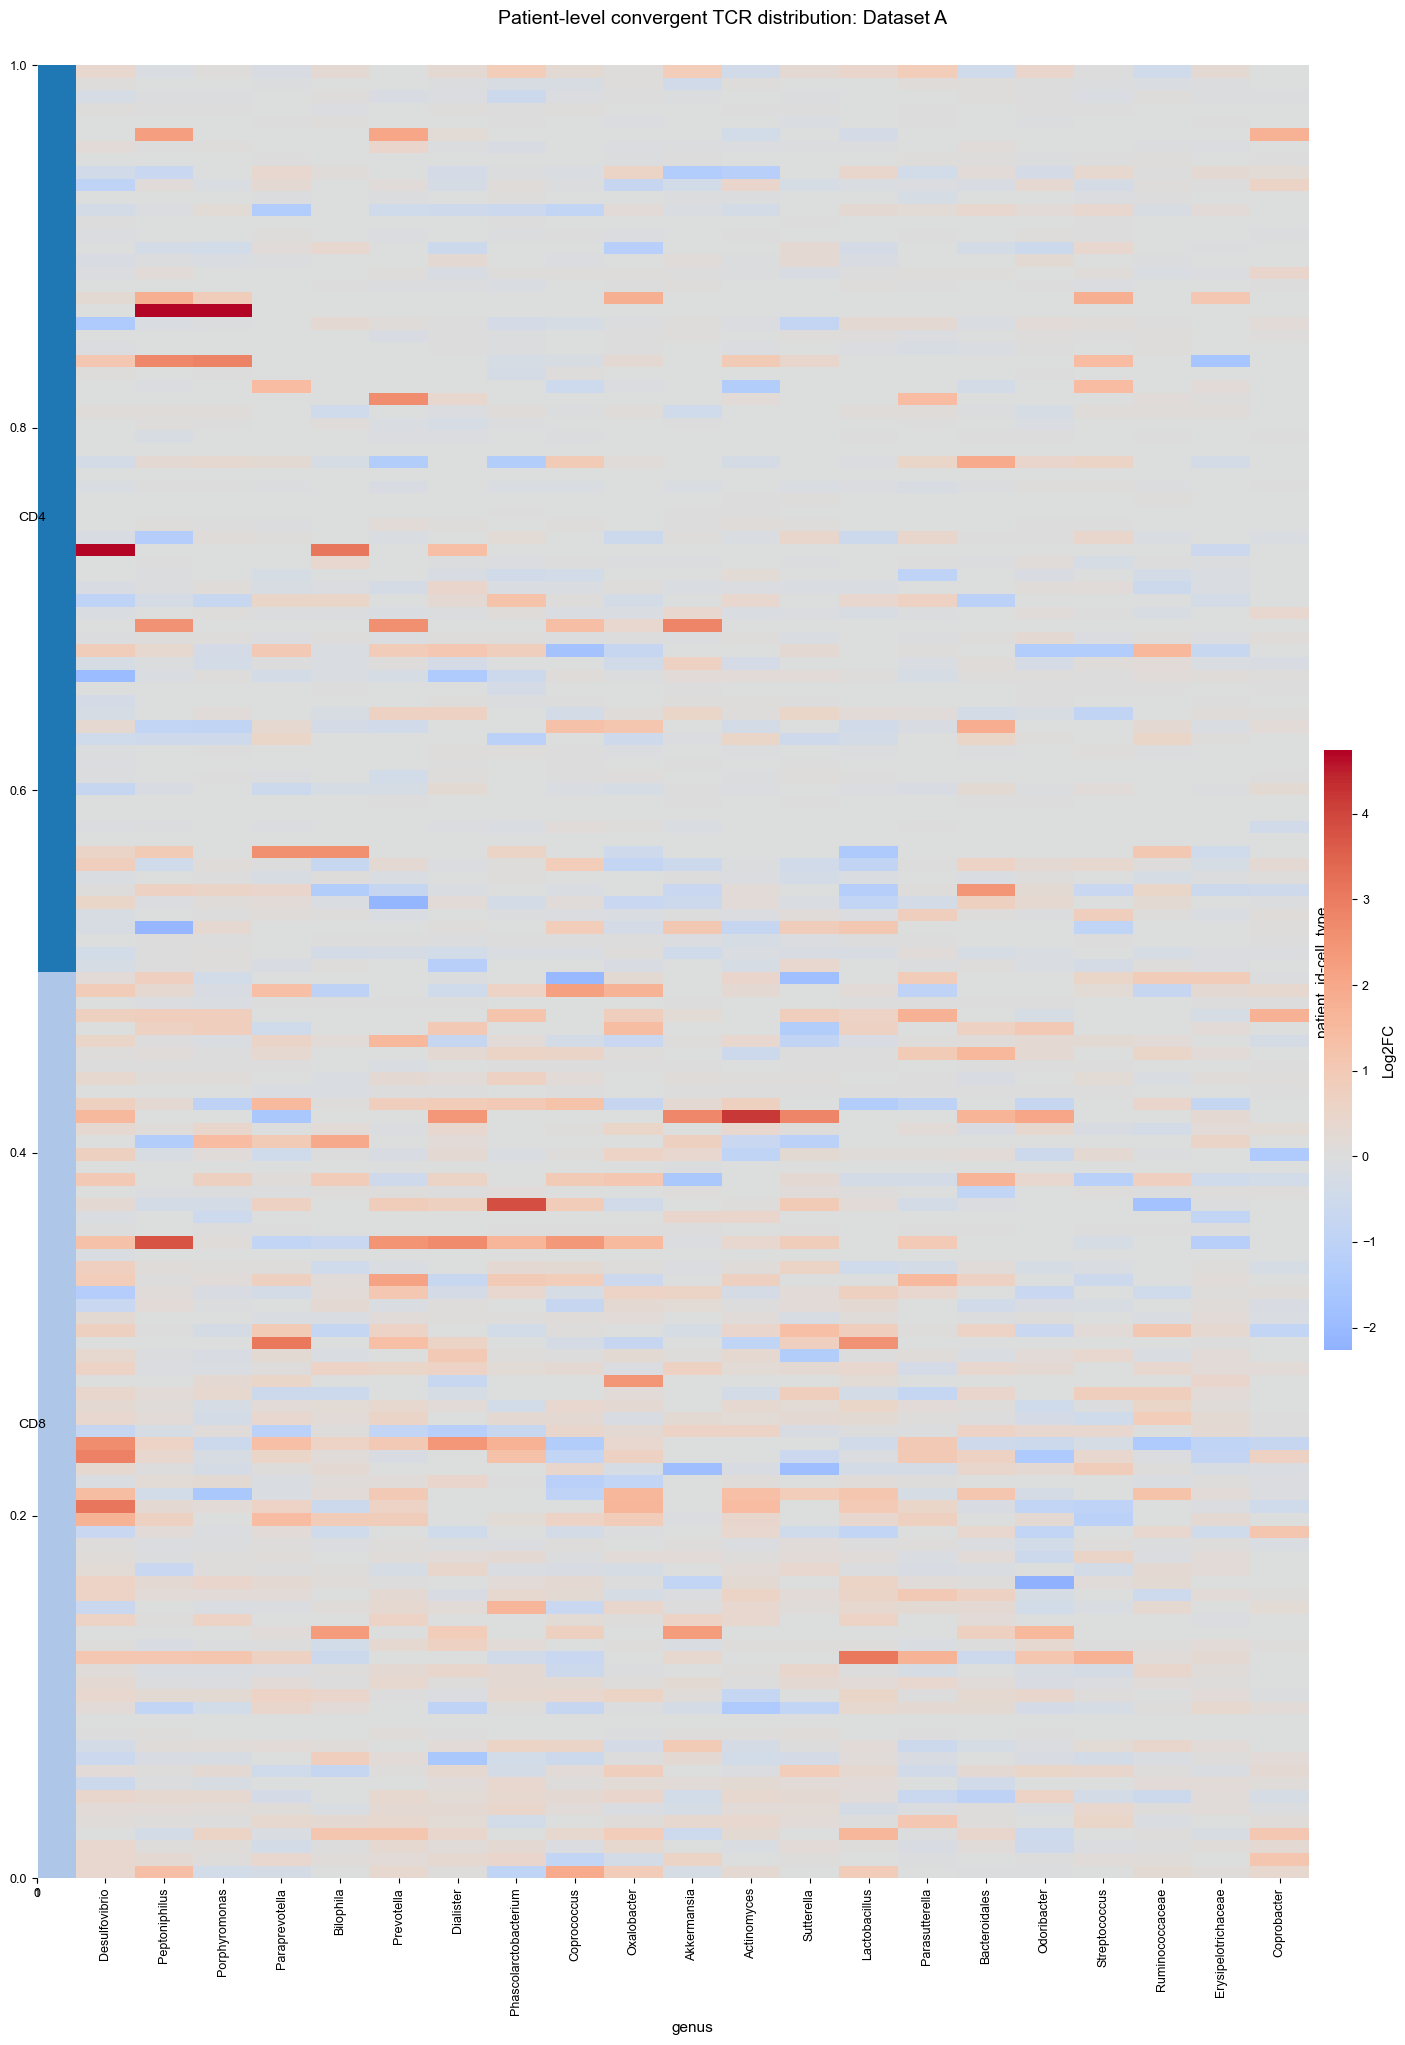

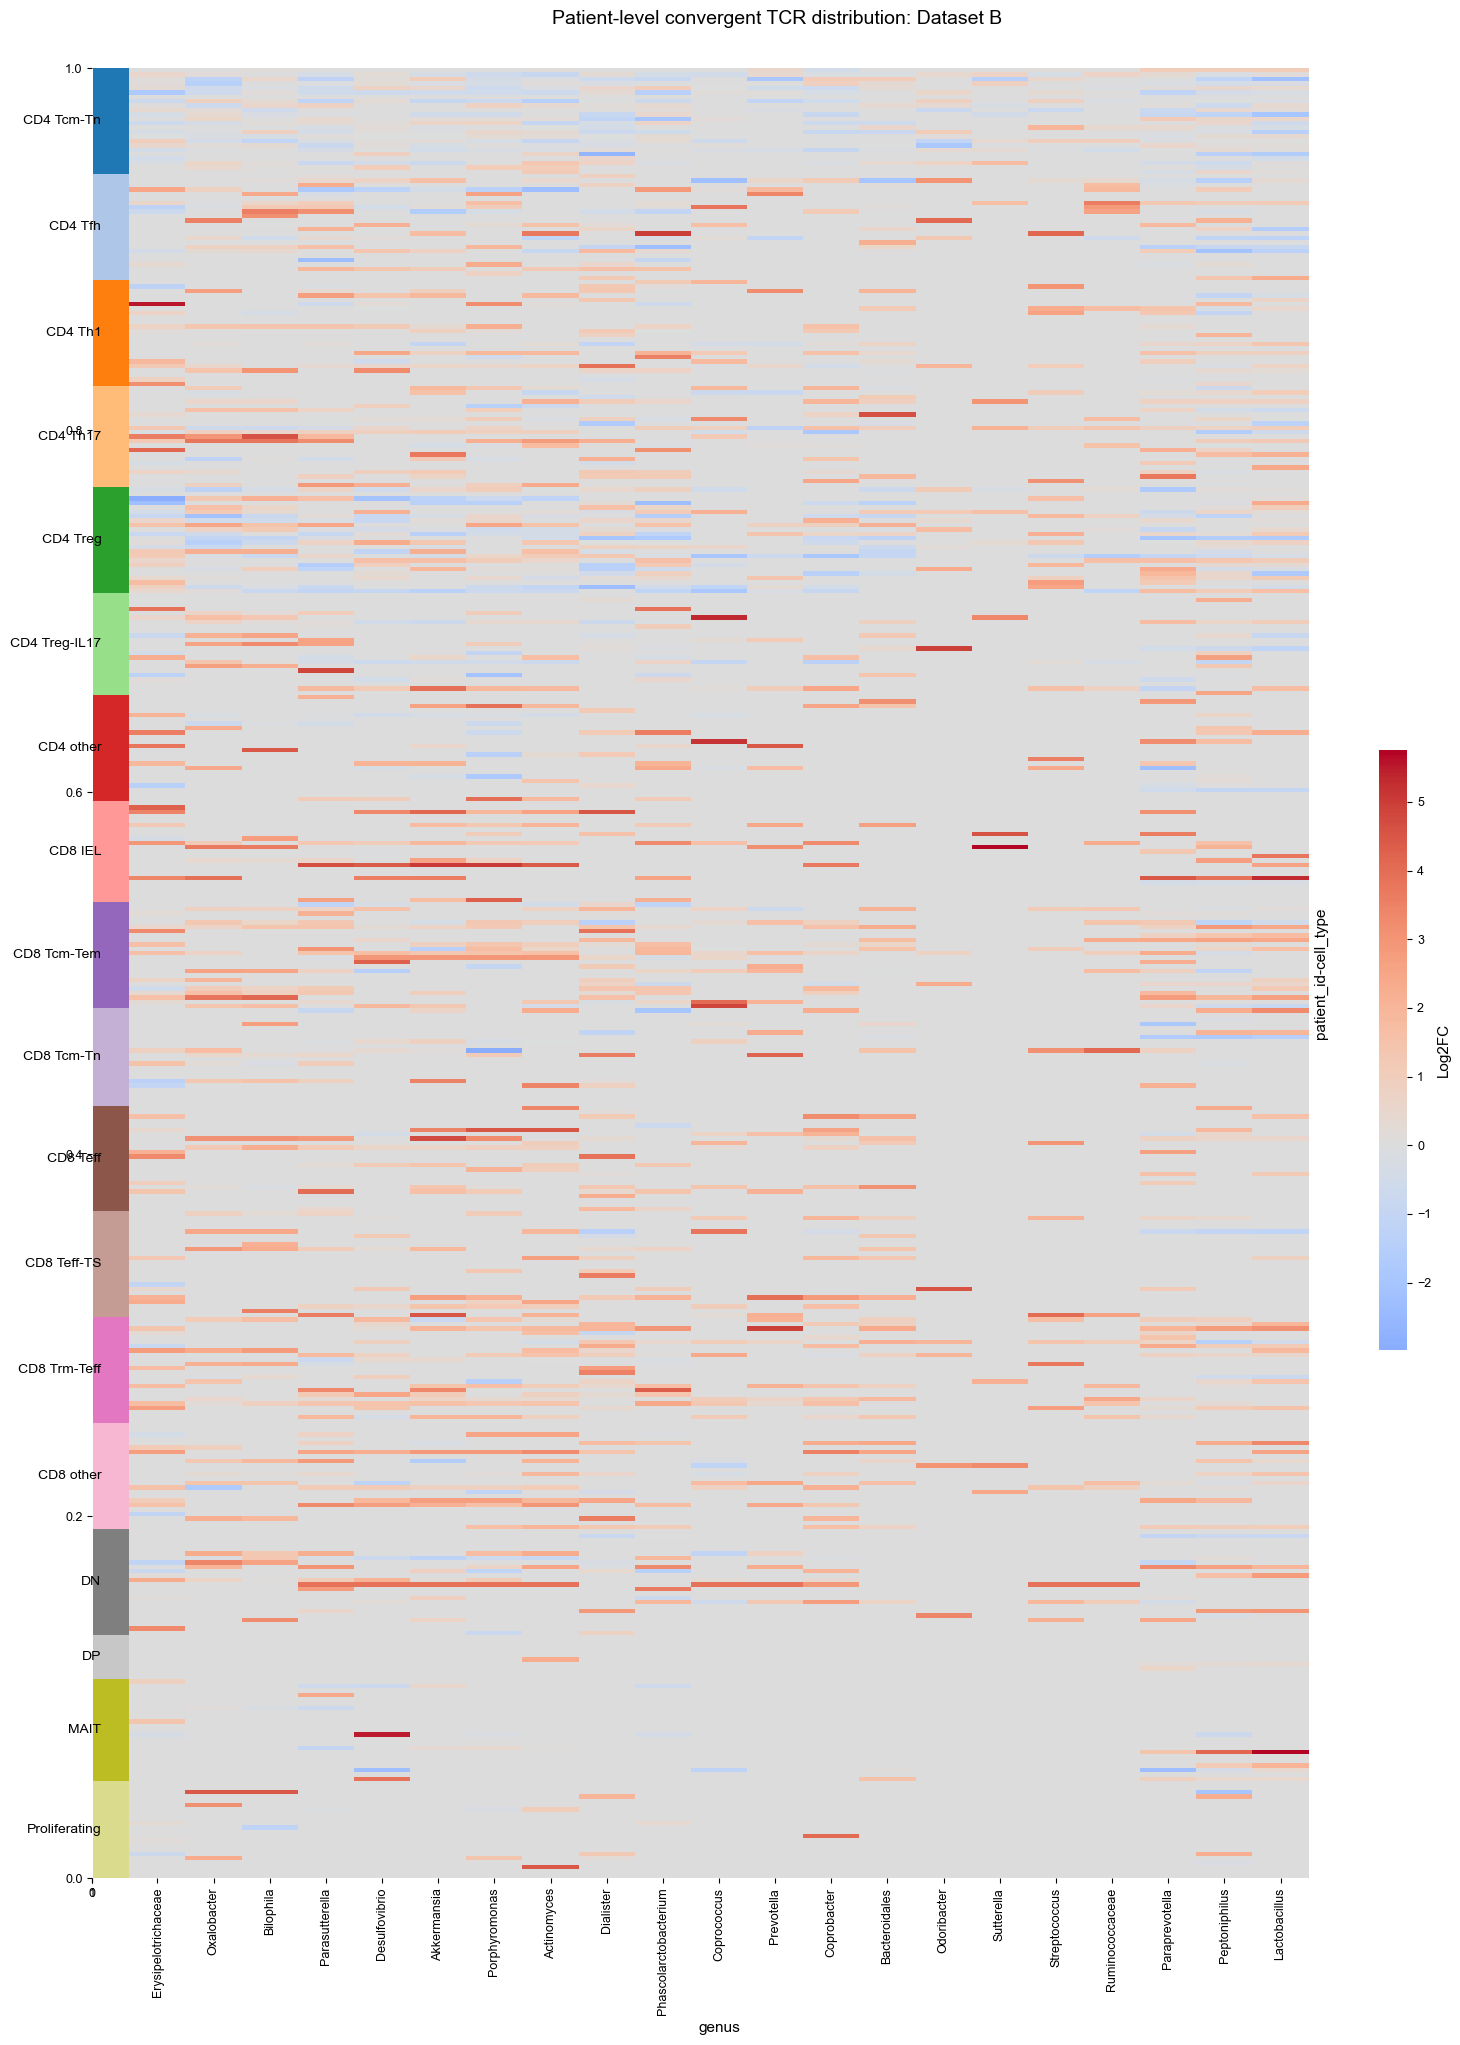

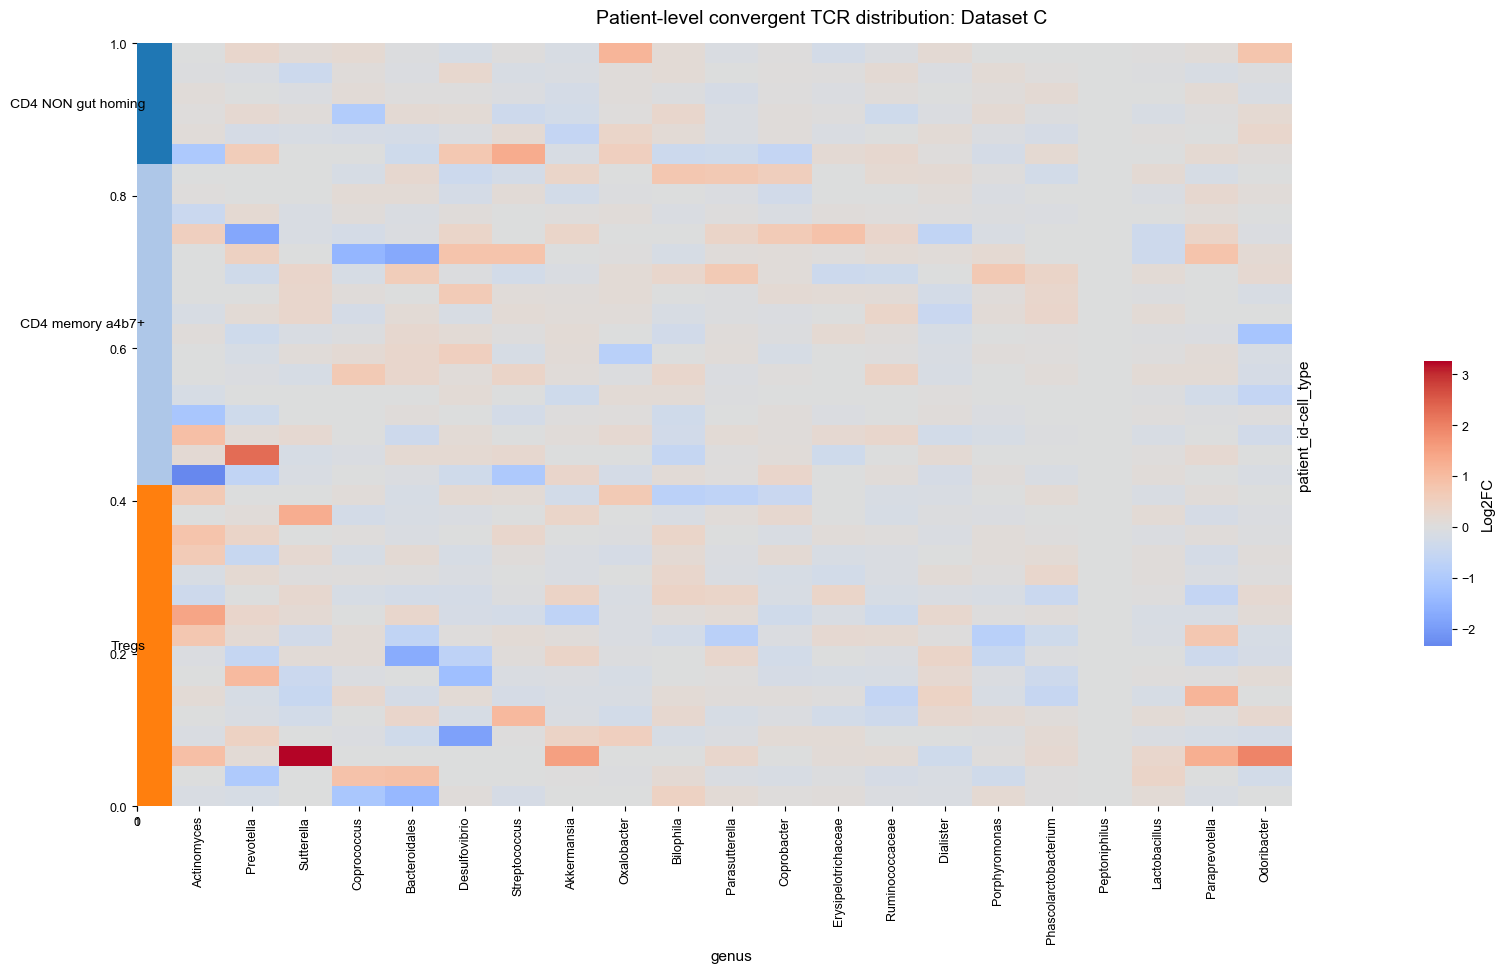

In [22]:
# Plot per dataset
for dataset_name in res_df_all["dataset"].unique():
    plot_patient_clustermap_middle_colorbar(heatmap, dataset_name, sorted_genera)

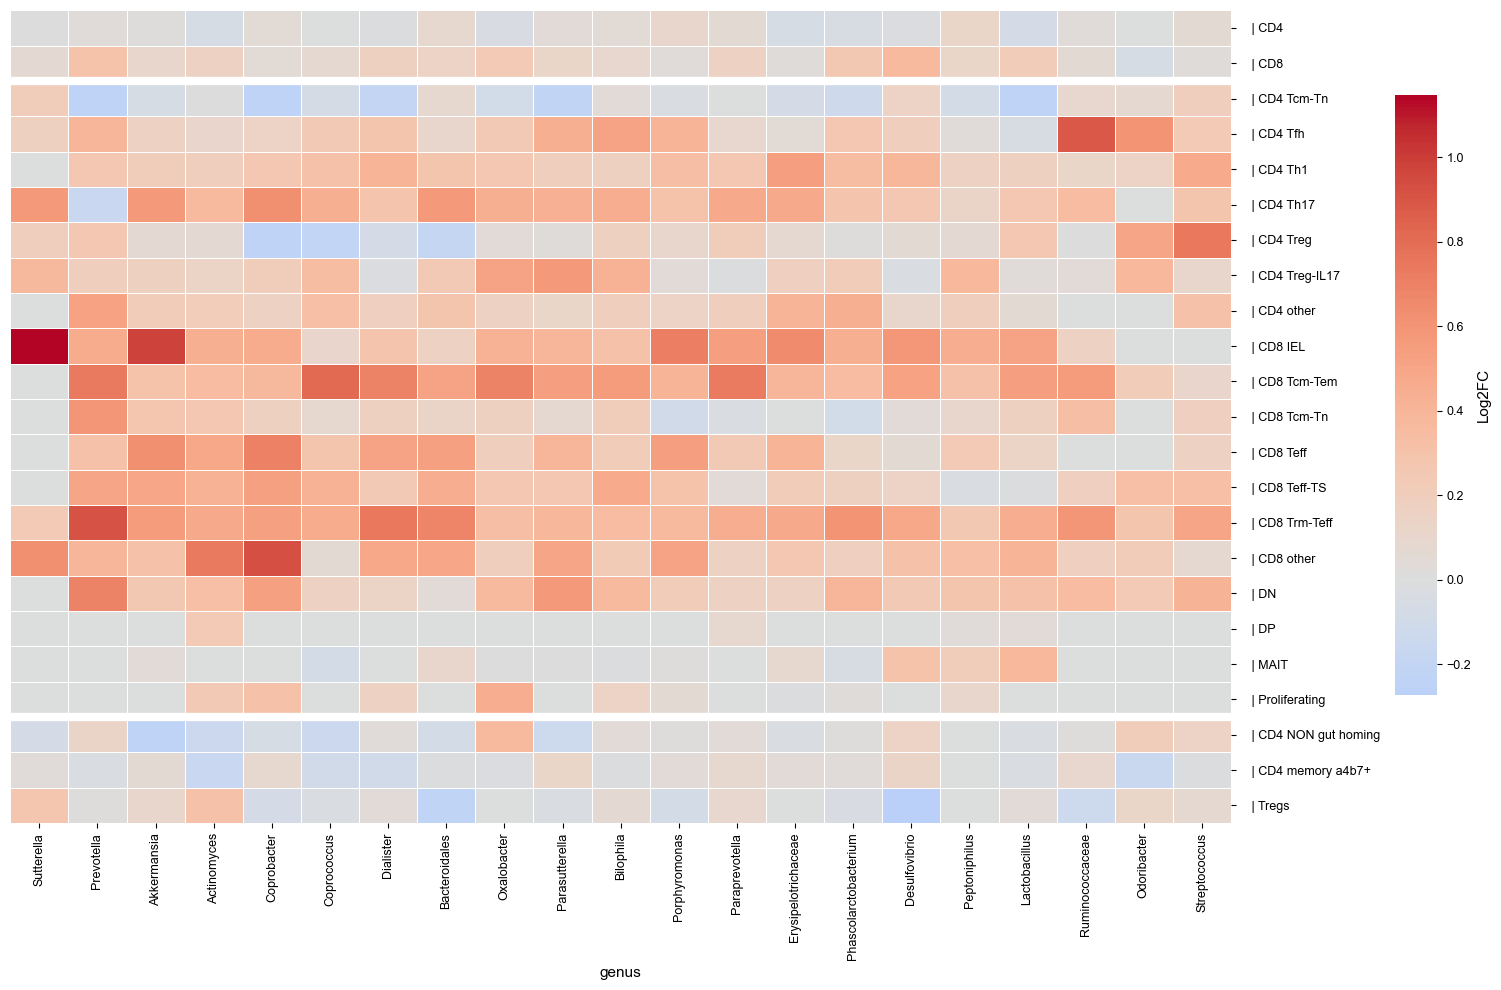

In [23]:
heatmap = res_df_all.pivot_table(
    index=["dataset", "cell_type"], columns="genus", values="Log2FC", aggfunc="mean"
)

heatmap = heatmap.reindex(columns=sorted_genera)
heatmap = heatmap.fillna(0)

row_order = []
for name, _, _ in datasets:
    cts = sorted(res_df_all.loc[res_df_all["dataset"] == name, "cell_type"].unique())
    row_order.extend([(name, ct) for ct in cts])

row_order = [idx for idx in row_order if idx in heatmap.index]
heatmap = heatmap.loc[row_order]
heatmap_disp = heatmap.copy()
heatmap_disp.index = [f"   | {ct}" for d, ct in heatmap.index]

g = sns.clustermap(
    heatmap_disp,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    row_cluster=False,
    col_cluster=True,
    figsize=(14, 10),
    dendrogram_ratio=(0.000001, 0.0000001),
    cbar_kws={"label": "Log2FC"},
    cbar_pos=(1.0, 0.3, 0.03, 0.6),
    xticklabels=True,
    yticklabels=True,
)


plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha="center")

row_counts = []
for name, _, _ in datasets:
    count = sum(heatmap.index.get_level_values(0) == name)
    if count > 0:
        row_counts.append(count)

boundaries = np.cumsum(row_counts)[:-1] if row_counts else []
for y in boundaries:
    g.ax_heatmap.hlines(y, *g.ax_heatmap.get_xlim(), colors="white", linewidth=6)

plt.title("", pad=20)
plt.savefig(figures_dir / "S8_T_cell_subtype_heatmap_all.pdf", bbox_inches="tight")
plt.show()